# Long-Time KdV Soliton Propagation Using Co-Moving Conservation-Regularized PINNs

**Publication notebook — version 1.0.0**

This notebook contains the cleaned computational workflow associated with the manuscript:

> *Long-Time KdV Soliton Propagation Using Co-Moving Conservation-Regularized Physics-Informed Neural Networks*

It supports two separate routes:

1. **Fast figure reproduction:** load the deposited processed archives and regenerate Figures 1–6 and Supplementary Figures S1–S3 without retraining.
2. **Optional full retraining:** regenerate the laboratory-frame and co-moving-frame Stage 1 and Stage 2 PINN solutions using the fixed configuration reported in the manuscript.

The complete exploratory notebook should be retained separately as a provenance record. This publication notebook excludes obsolete short-horizon experiments, duplicate diagnostics, conversational development notes, and stored exploratory outputs.

## How to use this notebook

### Route A — reproduce the publication figures

This is the recommended reviewer workflow and normally takes only a few minutes.

Place these files in `data/processed/`:

- `LAB_E1_core_archive.npz`
- `COMOV_E1_core_archive.npz`
- `COMOV_E1_residual_diag.npz`

Then run:

1. **Setup and configuration**
2. **Data inventory check**
3. **Figure 1**
4. **Figures 2–6 and Supplementary Figures S1–S3**
5. **Release manifest and headline-metric verification**

### Route B — full retraining

This route is computationally expensive. Run the two optional training cells only when a CUDA GPU is available. The reported final runs used an **NVIDIA Tesla T4**.

Full retraining creates:

- processed numerical archives in `data/processed/`;
- trained model bundles and weights in `data/models/`;
- publication figures and figure source data in `outputs/publication_figures/`.

A fixed seed is used for the controlled comparison, but bitwise-identical GPU retraining across different CUDA, PyTorch, driver, and hardware versions is not guaranteed.

### Repository data record

Replace `DATASET_DOI` below after the Zenodo Dataset record is created. Large `.npz` and `.pt` files should be deposited on Zenodo rather than committed directly to GitHub.

In [ ]:
# ============================================================
# SETUP — Google Drive project root, imports, environment, seed
# ============================================================

from __future__ import annotations

import csv
import gc
import hashlib
import json
import os
import platform
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import scipy
import torch
import torch.nn as nn
from matplotlib.ticker import ScalarFormatter

try:
    from scipy.stats import qmc

    HAS_SCIPY = True

except Exception:
    HAS_SCIPY = False


# ------------------------------------------------------------
# 1. Repository metadata
# ------------------------------------------------------------

SOFTWARE_VERSION = "1.0.0"
DATASET_DOI = "10.5281/zenodo.21497569"



# ------------------------------------------------------------
# 2. Google Drive project root
# ------------------------------------------------------------
#
# All input files, generated outputs, model weights, numerical
# archives, configuration files, and release files are stored under:
#
# My Drive/
# └── KdV_longtime_publication/
#
# Colab filesystem path:
#
# /content/drive/MyDrive/KdV_longtime_publication
# ------------------------------------------------------------

IN_GOOGLE_COLAB = "google.colab" in sys.modules

if not IN_GOOGLE_COLAB:
    raise RuntimeError(
        "This setup cell is configured for Google Colab. "
        "Open the notebook in Colab and run the cell again."
    )

try:
    from google.colab import drive  # type: ignore

    drive.mount(
        "/content/drive",
        force_remount=False,
    )

except Exception as exc:
    raise RuntimeError(
        "Google Drive could not be mounted."
    ) from exc


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/KdV_longtime_publication"
).resolve()

# Create the project folder if it does not already exist.
PROJECT_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# Make the Drive project folder the active Colab directory.
os.chdir(PROJECT_ROOT)

# Verify that the active working directory is correct.
if Path.cwd().resolve() != PROJECT_ROOT:
    raise RuntimeError(
        "The Colab working directory was not changed successfully."
    )


# ------------------------------------------------------------
# 3. Fixed folder hierarchy
# ------------------------------------------------------------

DATA_DIR = PROJECT_ROOT / "data"

# Numerical archives used to reproduce the publication figures.
ARCHIVE_DIR = DATA_DIR / "processed"

# Trained model bundles and PyTorch state dictionaries.
MODEL_DIR = DATA_DIR / "models"

# Canonical location for figure source-data exports (one location for
# both externally supplied and notebook-generated source data -- see
# Section C.3 of the reproducibility audit).
SOURCE_DATA_DIR = DATA_DIR / "source_data"
# Backward-compatible alias; some earlier notebook drafts referred to
# this directory as "input" source data.
INPUT_SOURCE_DATA_DIR = SOURCE_DATA_DIR

# All generated publication outputs.
OUTPUT_DIR = PROJECT_ROOT / "outputs"

# Frozen paper and numerical configuration files.
CONFIG_DIR = PROJECT_ROOT / "config"

# Environment, manifests, checksums, and release summaries.
RELEASE_DIR = PROJECT_ROOT / "release"

for directory in (
    DATA_DIR,
    ARCHIVE_DIR,
    MODEL_DIR,
    SOURCE_DATA_DIR,
    OUTPUT_DIR,
    CONFIG_DIR,
    RELEASE_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


# ------------------------------------------------------------
# 3b. Repair filename anomalies
# ------------------------------------------------------------
# Every downstream cell locates archives and models by an *exact*
# filename match (e.g. ARCHIVE_DIR / "LAB_E1_core_archive.npz"). A file
# saved or uploaded with stray leading/trailing whitespace in its name
# (e.g. " LAB_E1_core_archive.npz") is invisible to those exact-match
# lookups even though it appears in a plain `ls`/tree listing, and
# produces a FileNotFoundError with no indication of why. This scans
# the whole project tree once and repairs any such name in place.

def sanitize_filenames(root: Path, verbose: bool = True) -> list:
    """Rename any file or directory anywhere under `root` whose name
    has leading/trailing whitespace. Returns a list of (old, new) path
    pairs for every rename actually performed."""
    renamed = []
    if not root.exists():
        return renamed
    # Deepest entries first so renaming a parent directory never
    # invalidates the cached path of an already-discovered child.
    entries = sorted(
        root.rglob("*"),
        key=lambda p: len(p.parts),
        reverse=True,
    )
    for entry in entries:
        stripped = entry.name.strip()
        if stripped and stripped != entry.name:
            target = entry.parent / stripped
            if target.exists():
                print(
                    f"[skip] Cannot repair {str(entry)!r}: "
                    f"{target.name!r} already exists in the same folder."
                )
                continue
            entry.rename(target)
            renamed.append((entry, target))
            if verbose:
                print(f"[repaired] {str(entry)!r} -> {str(target)!r}")
    return renamed


print("\nScanning for filename anomalies (leading/trailing whitespace)...")
_repaired_names = sanitize_filenames(PROJECT_ROOT)
if _repaired_names:
    print(f"Repaired {len(_repaired_names)} file/folder name(s).")
else:
    print("No filename anomalies found.")


# ------------------------------------------------------------
# 4. Global numerical settings
# ------------------------------------------------------------

SAVE_WEIGHTS = True
SAVE_JSON_SUMMARY = True
USE_CORE_BIASED_SAMPLING = True

torch.set_default_dtype(
    torch.float32
)


def set_seed(
    seed: int = 1234,
) -> None:
    """Reset NumPy and PyTorch random generators."""

    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 1234
set_seed(SEED)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# Publication-friendly vector font embedding.
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["font.family"] = "sans-serif"


# ------------------------------------------------------------
# 5. Environment record
# ------------------------------------------------------------

environment = {
    "software_version": SOFTWARE_VERSION,
    "project_root": str(PROJECT_ROOT),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

environment_path = (
    RELEASE_DIR
    / "environment.json"
)

with environment_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        environment,
        file,
        indent=2,
    )


# ------------------------------------------------------------
# 6. Folder-tree display
# ------------------------------------------------------------

def print_directory_tree(
    root: Path,
    max_depth: int = 4,
) -> None:
    """Print files and directories below the project root."""

    root = root.resolve()

    print(f"\n{root.name}/")

    items = sorted(
        root.rglob("*"),
        key=lambda path: (
            len(
                path.relative_to(root).parts
            ),
            str(path).lower(),
        ),
    )

    for path in items:
        relative = path.relative_to(root)
        depth = len(relative.parts)

        if depth > max_depth:
            continue

        indent = "    " * (depth - 1)
        marker = "└── "

        anomaly = (
            "  [WARNING: leading/trailing whitespace in name]"
            if path.name != path.name.strip()
            else ""
        )

        if path.is_dir():
            print(
                f"{indent}{marker}{path.name}/{anomaly}"
            )

        else:
            size_kb = (
                path.stat().st_size
                / 1024
            )

            print(
                f"{indent}{marker}"
                f"{path.name} "
                f"({size_kb:.1f} KB){anomaly}"
            )


# ------------------------------------------------------------
# 7. Setup verification and summary
# ------------------------------------------------------------

EXPECTED_PROJECT_ROOT = Path(
    "/content/drive/MyDrive/KdV_longtime_publication"
).resolve()

assert PROJECT_ROOT == EXPECTED_PROJECT_ROOT
assert Path.cwd().resolve() == EXPECTED_PROJECT_ROOT

print("=" * 72)
print("KDV LONG-TIME PUBLICATION PROJECT")
print("=" * 72)

print(
    "Google Drive is mounted and the project folder "
    "is the active Colab working directory."
)

print()
print(f"Current directory      : {Path.cwd()}")
print(f"PROJECT_ROOT          : {PROJECT_ROOT}")
print(f"DATA_DIR              : {DATA_DIR}")
print(f"ARCHIVE_DIR           : {ARCHIVE_DIR}")
print(f"MODEL_DIR             : {MODEL_DIR}")
print(f"SOURCE_DATA_DIR       : {SOURCE_DATA_DIR}")
print(f"OUTPUT_DIR            : {OUTPUT_DIR}")
print(f"CONFIG_DIR            : {CONFIG_DIR}")
print(f"RELEASE_DIR           : {RELEASE_DIR}")
print(f"Device                : {device}")

print()
print("Environment:")
print(
    json.dumps(
        environment,
        indent=2,
    )
)

print_directory_tree(
    PROJECT_ROOT,
    max_depth=4,
)

Mounted at /content/drive

Scanning for filename anomalies (leading/trailing whitespace)...
No filename anomalies found.
KDV LONG-TIME PUBLICATION PROJECT
Google Drive is mounted and the project folder is the active Colab working directory.

Current directory      : /content/drive/MyDrive/KdV_longtime_publication
PROJECT_ROOT          : /content/drive/MyDrive/KdV_longtime_publication
DATA_DIR              : /content/drive/MyDrive/KdV_longtime_publication/data
ARCHIVE_DIR           : /content/drive/MyDrive/KdV_longtime_publication/data/processed
MODEL_DIR             : /content/drive/MyDrive/KdV_longtime_publication/data/models
SOURCE_DATA_DIR       : /content/drive/MyDrive/KdV_longtime_publication/data/source_data
OUTPUT_DIR            : /content/drive/MyDrive/KdV_longtime_publication/outputs
CONFIG_DIR            : /content/drive/MyDrive/KdV_longtime_publication/config
RELEASE_DIR           : /content/drive/MyDrive/KdV_longtime_publication/release
Device                : cuda

Environ

In [2]:
# ============================================================
# FROZEN PAPER CONFIGURATION
# ============================================================

PAPER_CONFIG = {
    "seed": 1234,
    "alpha": 6.0,
    "beta": 1.0,
    "amplitude": 0.5,
    "initial_center": -10.0,
    "speed": 1.0,
    "kappa": 0.5,
    "width_scale": 2.0,
    "domain_left": -30.0,
    "domain_right": 30.0,
    "tau_max": 80.0,
    "reference_grid_points": 1024,
    "reference_time_step": 1.0e-3,
    "reference_save_every": 1000,
    "reference_save_interval": 1.0,
    "periodic_ic_harmonics": 128,
    "spatial_fourier_harmonics": 10,
    "network_width": 128,
    "network_hidden_layers": 7,
    "input_feature_dimension": 25,
    "collocation_points": 70000,
    "background_sampling_fraction": 0.30,
    "laboratory_core_window_normalized_width": 16.0 / 30.0,
    "comoving_core_window_normalized_width": 0.15,
    "stage1_adam_steps": 2000,
    "stage1_adam_learning_rate": 1.0e-3,
    "stage1_lbfgs_points": 20000,
    "stage1_lbfgs_max_iterations": 1500,
    "stage2_anchor_points": 10000,
    "stage2_adam_steps": 2000,
    "stage2_adam_learning_rate": 5.0e-4,
    "stage2_pde_batch": 8192,
    "stage2_anchor_batch": 4096,
    "stage2_invariant_times": 20,
    "stage2_anchor_weight": 0.1,
    "stage2_invariant_weight_min": 1.0e-3,
    "stage2_invariant_weight_max": 1.0,
    "stage2_ramp_steps": 600,
    "stage2_lbfgs_points": 20000,
    "stage2_lbfgs_max_iterations": 1500,
    "pinn_dtype": "float32",
    "reported_gpu": "NVIDIA Tesla T4",
}

K_HARM = int(PAPER_CONFIG["spatial_fourier_harmonics"])
NETWORK_WIDTH = int(PAPER_CONFIG["network_width"])
N_HIDDEN_LAYERS = int(PAPER_CONFIG["network_hidden_layers"])
STAGE2_RAMP_STEPS = int(PAPER_CONFIG["stage2_ramp_steps"])

# Additional module-level aliases so the (optional) training cells read
# every scientific hyperparameter from PAPER_CONFIG instead of carrying
# duplicated hardcoded literals. Values are unchanged -- these are the
# same numbers the training cells already used.
PERIODIC_IC_HARMONICS = int(PAPER_CONFIG["periodic_ic_harmonics"])
COLLOCATION_POINTS = int(PAPER_CONFIG["collocation_points"])
BACKGROUND_SAMPLING_FRACTION = float(PAPER_CONFIG["background_sampling_fraction"])
LAB_CORE_WINDOW_NORMALIZED_WIDTH = float(PAPER_CONFIG["laboratory_core_window_normalized_width"])
COMOV_CORE_WINDOW_NORMALIZED_WIDTH = float(PAPER_CONFIG["comoving_core_window_normalized_width"])
STAGE1_ADAM_STEPS = int(PAPER_CONFIG["stage1_adam_steps"])
STAGE1_ADAM_LEARNING_RATE = float(PAPER_CONFIG["stage1_adam_learning_rate"])
STAGE1_LBFGS_POINTS = int(PAPER_CONFIG["stage1_lbfgs_points"])
STAGE1_LBFGS_MAX_ITERATIONS = int(PAPER_CONFIG["stage1_lbfgs_max_iterations"])
STAGE2_ANCHOR_POINTS = int(PAPER_CONFIG["stage2_anchor_points"])
STAGE2_ADAM_STEPS = int(PAPER_CONFIG["stage2_adam_steps"])
STAGE2_ADAM_LEARNING_RATE = float(PAPER_CONFIG["stage2_adam_learning_rate"])
STAGE2_PDE_BATCH = int(PAPER_CONFIG["stage2_pde_batch"])
STAGE2_ANCHOR_BATCH = int(PAPER_CONFIG["stage2_anchor_batch"])
STAGE2_INVARIANT_TIMES = int(PAPER_CONFIG["stage2_invariant_times"])
STAGE2_ANCHOR_WEIGHT = float(PAPER_CONFIG["stage2_anchor_weight"])
STAGE2_INVARIANT_WEIGHT_MIN = float(PAPER_CONFIG["stage2_invariant_weight_min"])
STAGE2_INVARIANT_WEIGHT_MAX = float(PAPER_CONFIG["stage2_invariant_weight_max"])
STAGE2_LBFGS_POINTS = int(PAPER_CONFIG["stage2_lbfgs_points"])
STAGE2_LBFGS_MAX_ITERATIONS = int(PAPER_CONFIG["stage2_lbfgs_max_iterations"])

# Basic internal checks.
assert PAPER_CONFIG["speed"] == (
    PAPER_CONFIG["alpha"] * PAPER_CONFIG["amplitude"] / 3.0
)
assert np.isclose(
    PAPER_CONFIG["width_scale"],
    np.sqrt(
        12.0 * PAPER_CONFIG["beta"]
        / (
            PAPER_CONFIG["alpha"]
            * PAPER_CONFIG["amplitude"]
        )
    ),
)
assert PAPER_CONFIG["input_feature_dimension"] == (
    2 * K_HARM + 5
)

config_path = CONFIG_DIR / "paper_config.json"
with config_path.open("w", encoding="utf-8") as file:
    json.dump(PAPER_CONFIG, file, indent=2)

print(f"[saved] {config_path}")
print(json.dumps(PAPER_CONFIG, indent=2))

[saved] /content/drive/MyDrive/KdV_longtime_publication/config/paper_config.json
{
  "seed": 1234,
  "alpha": 6.0,
  "beta": 1.0,
  "amplitude": 0.5,
  "initial_center": -10.0,
  "speed": 1.0,
  "kappa": 0.5,
  "width_scale": 2.0,
  "domain_left": -30.0,
  "domain_right": 30.0,
  "tau_max": 80.0,
  "reference_grid_points": 1024,
  "reference_time_step": 0.001,
  "reference_save_every": 1000,
  "reference_save_interval": 1.0,
  "periodic_ic_harmonics": 128,
  "spatial_fourier_harmonics": 10,
  "network_width": 128,
  "network_hidden_layers": 7,
  "input_feature_dimension": 25,
  "collocation_points": 70000,
  "background_sampling_fraction": 0.3,
  "laboratory_core_window_normalized_width": 0.5333333333333333,
  "comoving_core_window_normalized_width": 0.15,
  "stage1_adam_steps": 2000,
  "stage1_adam_learning_rate": 0.001,
  "stage1_lbfgs_points": 20000,
  "stage1_lbfgs_max_iterations": 1500,
  "stage2_anchor_points": 10000,
  "stage2_adam_steps": 2000,
  "stage2_adam_learning_rate": 0.

## Expected data layout

The Zenodo Dataset should be extracted under the repository root as follows:

```text
data/
├── processed/
│   ├── LAB_E1_core_archive.npz
│   ├── COMOV_E1_core_archive.npz
│   ├── COMOV_E1_residual_diag.npz
│   ├── LAB_E1_core_summary.json
│   └── COMOV_E1_core_summary.json
│
├── models/
│   ├── LAB_E1_model_bundle.npz
│   ├── COMOV_E1_model_bundle.npz
│   ├── LAB_E1_net1_stage1.pt
│   ├── LAB_E1_net2_stage2.pt
│   ├── COMOV_E1_net1_stage1.pt
│   └── COMOV_E1_net2_stage2.pt
│
└── source_data/
    └── deposited figure source-data files
```

Only the three processed archives are required for the fast publication-figure workflow. Model bundles and weights are required for inference or diagnostic regeneration from trained networks.

In [3]:
# ============================================================
# DATA INVENTORY CHECK
# ============================================================

REQUIRED_FOR_FIGURES = [
    ARCHIVE_DIR / "LAB_E1_core_archive.npz",
    ARCHIVE_DIR / "COMOV_E1_core_archive.npz",
    ARCHIVE_DIR / "COMOV_E1_residual_diag.npz",
]

REQUIRED_FOR_MODEL_REUSE = [
    MODEL_DIR / "LAB_E1_model_bundle.npz",
    MODEL_DIR / "COMOV_E1_model_bundle.npz",
    MODEL_DIR / "LAB_E1_net1_stage1.pt",
    MODEL_DIR / "LAB_E1_net2_stage2.pt",
    MODEL_DIR / "COMOV_E1_net1_stage1.pt",
    MODEL_DIR / "COMOV_E1_net2_stage2.pt",
]

def report_files(label: str, paths: list[Path]) -> list[Path]:
    print(f"\n{label}")
    print("-" * len(label))
    missing = []
    for path in paths:
        if path.is_file():
            size_mb = path.stat().st_size / (1024 ** 2)
            print(f"[OK]      {path.name:40s} {size_mb:9.3f} MB")
        else:
            missing.append(path)
            near_miss = None
            if path.parent.is_dir():
                for candidate in path.parent.iterdir():
                    if candidate.name != path.name and candidate.name.strip() == path.name:
                        near_miss = candidate.name
                        break
            if near_miss is not None:
                print(
                    f"[MISSING] {path}  "
                    f"(found near-match {near_miss!r} -- differs only by "
                    f"whitespace; re-run the setup cell to repair it)"
                )
            else:
                print(f"[MISSING] {path}")
    return missing

missing_figure_files = report_files(
    "Files required for figure reproduction",
    REQUIRED_FOR_FIGURES,
)

missing_model_files = report_files(
    "Files required for trained-model reuse",
    REQUIRED_FOR_MODEL_REUSE,
)

if missing_figure_files:
    print(
        "\nFigure reproduction is not ready. Place the missing processed "
        "archives in data/processed/ or run the optional training cells."
    )
else:
    print("\nFigure reproduction inputs are complete.")

if missing_model_files:
    print(
        "Model reuse is optional. Missing model artifacts do not prevent "
        "figure reproduction from the processed archives."
    )


Files required for figure reproduction
--------------------------------------
[OK]      LAB_E1_core_archive.npz                      0.595 MB
[OK]      COMOV_E1_core_archive.npz                    0.851 MB
[OK]      COMOV_E1_residual_diag.npz                   0.032 MB

Files required for trained-model reuse
--------------------------------------
[OK]      LAB_E1_model_bundle.npz                      0.004 MB
[OK]      COMOV_E1_model_bundle.npz                    0.005 MB
[OK]      LAB_E1_net1_stage1.pt                        0.397 MB
[OK]      LAB_E1_net2_stage2.pt                        0.397 MB
[OK]      COMOV_E1_net1_stage1.pt                      0.397 MB
[OK]      COMOV_E1_net2_stage2.pt                      0.397 MB

Figure reproduction inputs are complete.


# Fast reproduction of the published figures

The next two cells load the saved archives only. They do **not** train a neural network and do not modify the numerical values.

- The first cell generates the matched frame-by-stage ablation summary.
- The second generates Figures 2–6, Supplementary Figures S1–S3, and all figure source-data files.

Publication files are written under:

```text
outputs/publication_figures/
```

[loaded] /content/drive/MyDrive/KdV_longtime_publication/data/processed/LAB_E1_core_archive.npz
[loaded] /content/drive/MyDrive/KdV_longtime_publication/data/processed/COMOV_E1_core_archive.npz
[info] archived L (soliton width scale) = 2 — not plotted as a threshold
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure1_ablation_summary_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/eps/Figure1_ablation_summary.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure1_ablation_summary.png


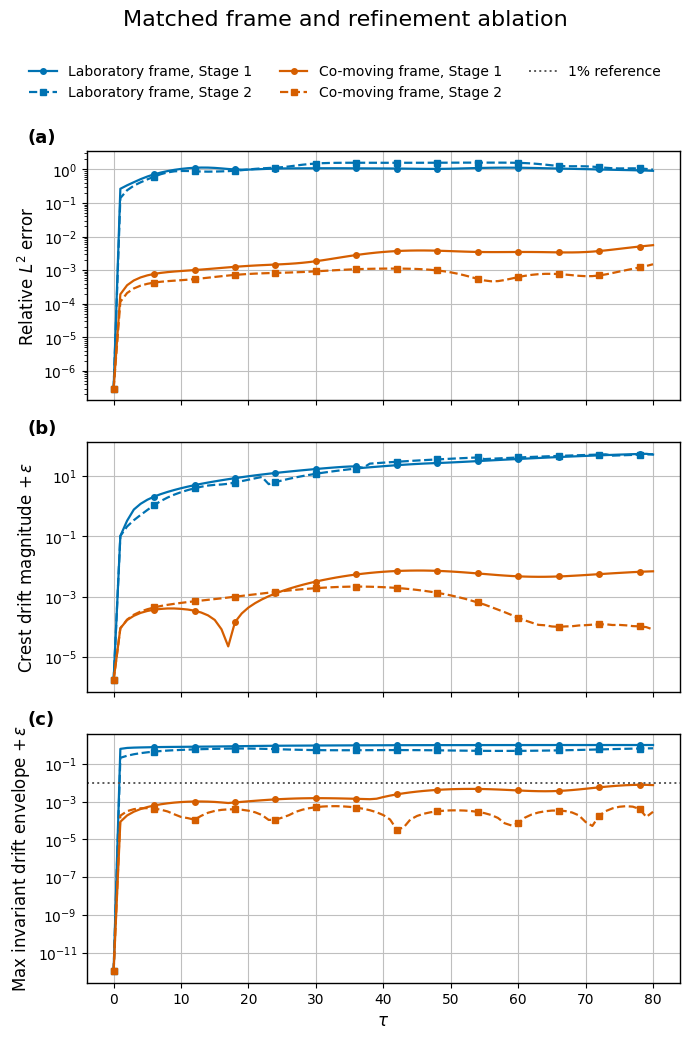

[saved][source data] /content/drive/MyDrive/KdV_longtime_publication/data/source_data/Figure1_source_data.csv

[done] Figure 1 generated from saved archives only.


In [4]:
# ============================================================
# FIGURE 1 — MATCHED 2x2 (frame x stage) ABLATION SUMMARY
# Loads saved lab-frame and co-moving-frame archives only.
# No numerical values are modified anywhere in this cell.
# ============================================================

import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ------------------------------------------------------------
# 0. Paths
# ------------------------------------------------------------
# PROJECT_ROOT, ARCHIVE_DIR, OUTPUT_DIR, and other paths are defined
# once in the setup cell near the top of this notebook.
PUB_ROOT = str(OUTPUT_DIR / "publication_figures")

PUB_DIRS = {
    "eps": os.path.join(PUB_ROOT, "eps"),
    "png": os.path.join(PUB_ROOT, "png"),
    "tiff": os.path.join(PUB_ROOT, "tiff"),
    "colab_preview": os.path.join(PUB_ROOT, "colab_previews"),
    # Canonical location (see setup cell): data/source_data, not a
    # subfolder of the figures output directory.
    "source_data": str(SOURCE_DATA_DIR),
    "diagnostic_panels": os.path.join(PUB_ROOT, "diagnostic_panels"),
    "supplementary_eps": os.path.join(PUB_ROOT, "supplementary", "eps"),
    "supplementary_png": os.path.join(PUB_ROOT, "supplementary", "png"),
    "supplementary_preview": os.path.join(PUB_ROOT, "supplementary", "colab_previews"),
}
for directory in PUB_DIRS.values():
    os.makedirs(directory, exist_ok=True)

SUPP_DIRS = {
    "eps": PUB_DIRS["supplementary_eps"],
    "png": PUB_DIRS["supplementary_png"],
    "colab_preview": PUB_DIRS["supplementary_preview"],
}

# ------------------------------------------------------------
# 1. Style constants
# ------------------------------------------------------------
TITLE_FS  = 16   # Colab-only notebook titles
LABEL_FS  = 12   # axis labels (kept in publication export)
TICK_FS   = 10
LEGEND_FS = 10
PANEL_LABEL_FS = 13
OFFSET_FS = 10

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": TICK_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEGEND_FS,
    "axes.edgecolor": "black",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
})

# Colour-blind-safe palette (Okabe-Ito)
COLOR_LAB   = "#0072B2"  # blue    -> Laboratory frame
COLOR_COMOV = "#D55E00"  # vermillion -> Co-moving frame

STYLE = {
    ("lab", 1):   dict(color=COLOR_LAB,   ls="-",  marker="o", label="Laboratory frame, Stage 1"),
    ("lab", 2):   dict(color=COLOR_LAB,   ls="--", marker="s", label="Laboratory frame, Stage 2"),
    ("comov", 1): dict(color=COLOR_COMOV, ls="-",  marker="o", label="Co-moving frame, Stage 1"),
    ("comov", 2): dict(color=COLOR_COMOV, ls="--", marker="s", label="Co-moving frame, Stage 2"),
}
MARKEVERY_FRAC = 12

# ------------------------------------------------------------
# 2. Validation helpers
# ------------------------------------------------------------
def require_file(path, hint):
    if not os.path.isfile(path):
        directory = os.path.dirname(path)
        target_name = os.path.basename(path)
        near_miss = None
        if os.path.isdir(directory):
            for candidate in os.listdir(directory):
                if candidate != target_name and candidate.strip() == target_name:
                    near_miss = candidate
                    break
        if near_miss is not None:
            raise FileNotFoundError(
                f"Missing archive:\n{path}\n{hint}\n"
                f"A near-match file was found instead: {near_miss!r} "
                f"(differs only by leading/trailing whitespace in the name). "
                f"Re-run the setup cell near the top of this notebook -- it "
                f"repairs filename anomalies like this automatically -- then retry."
            )
        raise FileNotFoundError(f"Missing archive:\n{path}\n{hint}")

def require_keys(npz, keys, archive_name):
    missing = [k for k in keys if k not in npz.files]
    if missing:
        raise KeyError(
            f"Archive '{archive_name}' is missing expected key(s): {missing}. "
            f"Available keys: {list(npz.files)}"
        )

def check_finite(arr, name):
    if not np.all(np.isfinite(arr)):
        n_bad = int(np.sum(~np.isfinite(arr)))
        raise ValueError(f"Array '{name}' contains {n_bad} non-finite value(s) (NaN/Inf).")

def check_same_shape(a, b, name_a, name_b):
    if np.shape(a) != np.shape(b):
        raise ValueError(f"Shape mismatch: {name_a} has shape {np.shape(a)}, "
                          f"{name_b} has shape {np.shape(b)}.")

def check_ndim(arr, name, ndim):
    if np.ndim(arr) != ndim:
        raise ValueError(f"Array '{name}' has ndim={np.ndim(arr)}, expected {ndim}.")

# ------------------------------------------------------------
# 3. Load archives
# ------------------------------------------------------------
lab_path = os.path.join(ARCHIVE_DIR, "LAB_E1_core_archive.npz")
com_path = os.path.join(ARCHIVE_DIR, "COMOV_E1_core_archive.npz")

require_file(lab_path, "Run the lab-frame training/archive cell first.")
require_file(com_path, "Run the co-moving training/archive cell first.")

LAB = np.load(lab_path, allow_pickle=False)
COM = np.load(com_path, allow_pickle=False)
print("[loaded]", lab_path)
print("[loaded]", com_path)

REQUIRED_KEYS = [
    "tau_ref", "relL2_stage1", "relL2_stage2",
    "crest_shift_stage1", "crest_shift_stage2",
    "dI1_stage1", "dI2_stage1", "dI3_stage1",
    "dI1_stage2", "dI2_stage2", "dI3_stage2",
]
require_keys(LAB, REQUIRED_KEYS, "LAB_E1_core_archive.npz")
require_keys(COM, REQUIRED_KEYS + ["L"], "COMOV_E1_core_archive.npz")

tau_lab = LAB["tau_ref"]
tau_com = COM["tau_ref"]
check_ndim(tau_lab, "LAB tau_ref", 1)
check_ndim(tau_com, "COM tau_ref", 1)
check_finite(tau_lab, "LAB tau_ref")
check_finite(tau_com, "COM tau_ref")

if len(tau_lab) != len(tau_com) or not np.allclose(tau_lab, tau_com):
    raise ValueError(
        "LAB and COMOV archives do not share the same saved tau grid. "
        "Refusing to plot mismatched time axes."
    )
tau = tau_lab
eps = 1e-12

def load_series(D, key):
    arr = D[key]
    check_ndim(arr, key, 1)
    check_finite(arr, key)
    check_same_shape(arr, tau, key, "tau_ref")
    return arr

lab_relL2_s1 = load_series(LAB, "relL2_stage1")
lab_relL2_s2 = load_series(LAB, "relL2_stage2")
com_relL2_s1 = load_series(COM, "relL2_stage1")
com_relL2_s2 = load_series(COM, "relL2_stage2")

lab_crest_s1 = load_series(LAB, "crest_shift_stage1")
lab_crest_s2 = load_series(LAB, "crest_shift_stage2")
com_crest_s1 = load_series(COM, "crest_shift_stage1")
com_crest_s2 = load_series(COM, "crest_shift_stage2")

def inv_envelope_from_archive(D, stage):
    d1 = load_series(D, f"dI1_{stage}")
    d2 = load_series(D, f"dI2_{stage}")
    d3 = load_series(D, f"dI3_{stage}")
    return np.maximum.reduce([np.abs(d1), np.abs(d2), np.abs(d3)])

lab_inv_s1 = inv_envelope_from_archive(LAB, "stage1")
lab_inv_s2 = inv_envelope_from_archive(LAB, "stage2")
com_inv_s1 = inv_envelope_from_archive(COM, "stage1")
com_inv_s2 = inv_envelope_from_archive(COM, "stage2")

# The archived 'L' is the soliton width scale (L = sqrt(12*beta/(alpha*A))),
# used upstream only for windowing (crest-tracking window, residual window).
# It has no documented meaning as a formal crest-drift tolerance anywhere in
# the training/archive code, so it is reported here for reference only and
# is NOT drawn as a threshold line on the ablation figure.
L_value = float(np.asarray(COM["L"]).reshape(-1)[0])
print(f"[info] archived L (soliton width scale) = {L_value:.6g} — not plotted as a threshold")

# ------------------------------------------------------------
# 4. Save functions — three single-purpose functions, each writes
#    exactly one artifact class. No function silently saves every
#    format regardless of why it was called.
# ------------------------------------------------------------
def save_colab_preview(fig, path, dpi=600):
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved][preview] {path}")

def save_publication_vector(fig, eps_path, png_path, dpi=600):
    fig.savefig(eps_path, format="eps", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication EPS] {eps_path}")
    fig.savefig(png_path, format="png", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication PNG] {png_path}")

def export_figure_vector(fig, set_title_fn, clear_title_fn, preview_path, eps_path, png_path):
    """
    Exact 7-step workflow:
      1. figure already built with its Colab title (caller's responsibility)
      2. save the title-bearing Colab preview -- once
      3. clear only the notebook-style title
      4. save the publication EPS + PNG -- once
      5. restore the title
      6. plt.show() the titled version
      7. plt.close(fig)
    Each underlying file path is written by exactly one savefig call.
    """
    set_title_fn()
    fig.canvas.draw()
    save_colab_preview(fig, preview_path)

    clear_title_fn()
    fig.canvas.draw()
    save_publication_vector(fig, eps_path, png_path)

    set_title_fn()
    fig.canvas.draw()
    plt.show()
    plt.close(fig)

def style_log_axis(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_yscale("log")
    ax.grid(True, which="major", axis="both", color="0.75", linewidth=0.8)
    ax.grid(False, which="minor", axis="y")
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.yaxis.get_offset_text().set_size(OFFSET_FS)
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

def plot_series(ax, x, y, frame, stage, eps_offset=0.0):
    s = STYLE[(frame, stage)]
    ax.semilogy(
        x, y + eps_offset,
        color=s["color"], ls=s["ls"], marker=s["marker"],
        lw=1.6, ms=4.0, markevery=max(1, len(x) // MARKEVERY_FRAC),
        label=s["label"],
    )

# ------------------------------------------------------------
# 5. Build Figure 1 (3 vertical panels, matched ablation)
# ------------------------------------------------------------
fig1, axes1 = plt.subplots(3, 1, figsize=(7.0, 9.5), sharex=True)
ax_a, ax_b, ax_c = axes1

plot_series(ax_a, tau, lab_relL2_s1, "lab", 1)
plot_series(ax_a, tau, lab_relL2_s2, "lab", 2)
plot_series(ax_a, tau, com_relL2_s1, "comov", 1)
plot_series(ax_a, tau, com_relL2_s2, "comov", 2)
style_log_axis(ax_a, ylabel=r"Relative $L^2$ error")
ax_a.text(-0.10, 1.02, "(a)", transform=ax_a.transAxes,
          fontsize=PANEL_LABEL_FS, fontweight="bold", va="bottom")

plot_series(ax_b, tau, np.abs(lab_crest_s1), "lab", 1, eps_offset=eps)
plot_series(ax_b, tau, np.abs(lab_crest_s2), "lab", 2, eps_offset=eps)
plot_series(ax_b, tau, np.abs(com_crest_s1), "comov", 1, eps_offset=eps)
plot_series(ax_b, tau, np.abs(com_crest_s2), "comov", 2, eps_offset=eps)
style_log_axis(ax_b, ylabel=r"Crest drift magnitude $+\,\varepsilon$")
ax_b.text(-0.10, 1.02, "(b)", transform=ax_b.transAxes,
          fontsize=PANEL_LABEL_FS, fontweight="bold", va="bottom")

plot_series(ax_c, tau, lab_inv_s1, "lab", 1, eps_offset=eps)
plot_series(ax_c, tau, lab_inv_s2, "lab", 2, eps_offset=eps)
plot_series(ax_c, tau, com_inv_s1, "comov", 1, eps_offset=eps)
plot_series(ax_c, tau, com_inv_s2, "comov", 2, eps_offset=eps)
ax_c.axhline(1e-2, color="0.35", ls=":", lw=1.4, label="1% reference")
style_log_axis(ax_c, xlabel=r"$\tau$", ylabel=r"Max invariant drift envelope $+\,\varepsilon$")
ax_c.text(-0.10, 1.02, "(c)", transform=ax_c.transAxes,
          fontsize=PANEL_LABEL_FS, fontweight="bold", va="bottom")

handles, labels = ax_a.get_legend_handles_labels()
extra_h, extra_l = ax_c.get_legend_handles_labels()
handles += [h for h, l in zip(extra_h, extra_l) if l == "1% reference"]
labels += [l for l in extra_l if l == "1% reference"]
# frameon=False: opaque-legend audit -- avoids the default framealpha=0.8
# semi-transparent legend box, which triggers EPS transparency warnings.
fig1.legend(handles, labels, loc="upper center", ncol=3,
            bbox_to_anchor=(0.5, 1.045), fontsize=LEGEND_FS, frameon=False)

NOTEBOOK_TITLE_1 = "Matched frame and refinement ablation"

def set_title_1():
    fig1.suptitle(NOTEBOOK_TITLE_1, fontsize=TITLE_FS, y=1.09)

def clear_title_1():
    if fig1._suptitle is not None:
        fig1._suptitle.set_text("")

fig1.tight_layout(rect=[0, 0, 1, 0.98])

preview_path_1 = os.path.join(PUB_DIRS["colab_preview"], "Figure1_ablation_summary_colab_preview.png")
eps_path_1 = os.path.join(PUB_DIRS["eps"], "Figure1_ablation_summary.eps")
png_path_1 = os.path.join(PUB_DIRS["png"], "Figure1_ablation_summary.png")

export_figure_vector(fig1, set_title_1, clear_title_1, preview_path_1, eps_path_1, png_path_1)

# ------------------------------------------------------------
# 6. Source data export (Figure 1) — raw archived values, unmodified
# ------------------------------------------------------------
src_path = os.path.join(PUB_DIRS["source_data"], "Figure1_source_data.csv")
with open(src_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "tau",
        "lab_relL2_stage1", "lab_relL2_stage2", "comov_relL2_stage1", "comov_relL2_stage2",
        "lab_crest_stage1", "lab_crest_stage2", "comov_crest_stage1", "comov_crest_stage2",
        "lab_invenv_stage1", "lab_invenv_stage2", "comov_invenv_stage1", "comov_invenv_stage2",
    ])
    for row in zip(
        tau,
        lab_relL2_s1, lab_relL2_s2, com_relL2_s1, com_relL2_s2,
        lab_crest_s1, lab_crest_s2, com_crest_s1, com_crest_s2,
        lab_inv_s1, lab_inv_s2, com_inv_s1, com_inv_s2,
    ):
        writer.writerow(row)
print(f"[saved][source data] {src_path}")

print("\n[done] Figure 1 generated from saved archives only.")


[info] legacy outputs/publication_figures/source_data folder present, but canonical data/source_data is not yet fully populated -- leaving the legacy folder in place until this cell has produced every source-data file.
[loaded] core archive: /content/drive/MyDrive/KdV_longtime_publication/data/processed/COMOV_E1_core_archive.npz
[check] core archive dimension/shape/finiteness validation passed.
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure2_comoving_relative_L2_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/eps/Figure2_comoving_relative_L2.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure2_comoving_relative_L2.png


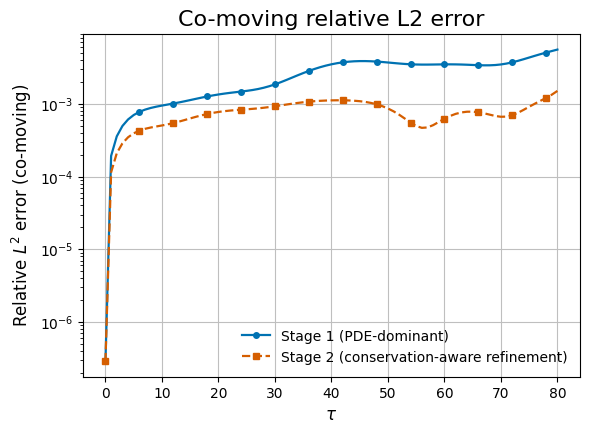

[saved][source data] Figure2_source_data.csv
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure3_comoving_crest_drift_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/eps/Figure3_comoving_crest_drift.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure3_comoving_crest_drift.png


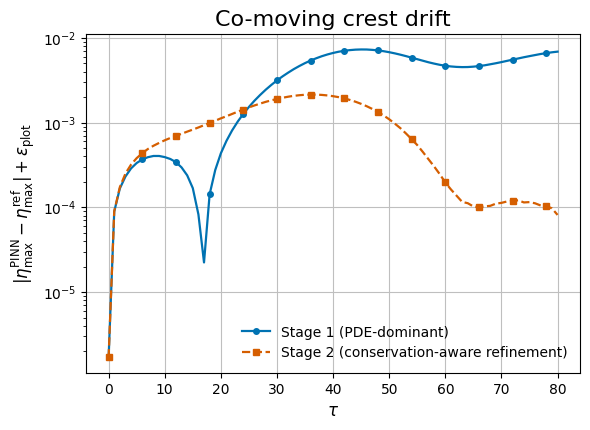

[saved][source data] Figure3_source_data.csv
[check] max |Stage 1 invariant drift| = 7.701e-03 (axis display uses a fixed power of 1e-3 for readability; ScalarFormatter power limits do not clip plotted values)
[check] max |Stage 2 invariant drift| = 5.691e-04 (axis display uses a fixed power of 1e-4 for readability; ScalarFormatter power limits do not clip plotted values)
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure4_invariant_drift_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/eps/Figure4_invariant_drift.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure4_invariant_drift.png


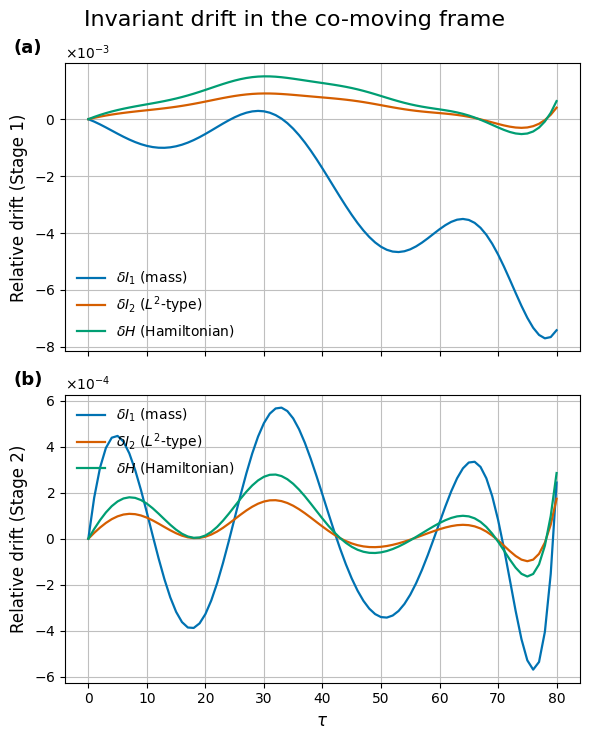

[saved][source data] Figure4_source_data.npz
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure5_spacetime_absolute_error_colab_preview.png
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure5_spacetime_absolute_error.png
[saved][publication TIFF] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/tiff/Figure5_spacetime_absolute_error.tiff


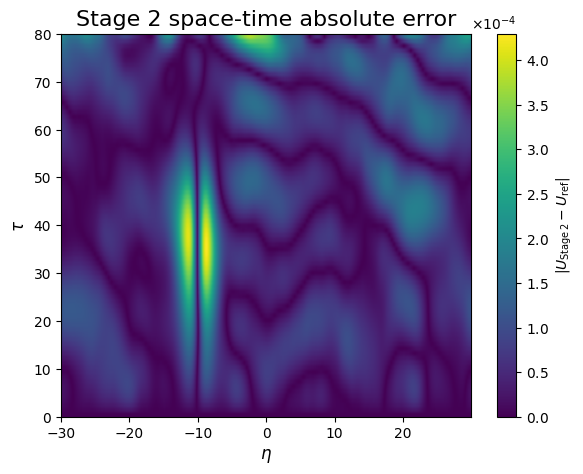

[saved][source data] Figure5_source_data.npz
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/colab_previews/Supplementary_Figure_S3_snapshot_overlays_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/eps/Supplementary_Figure_S3_snapshot_overlays.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/png/Supplementary_Figure_S3_snapshot_overlays.png


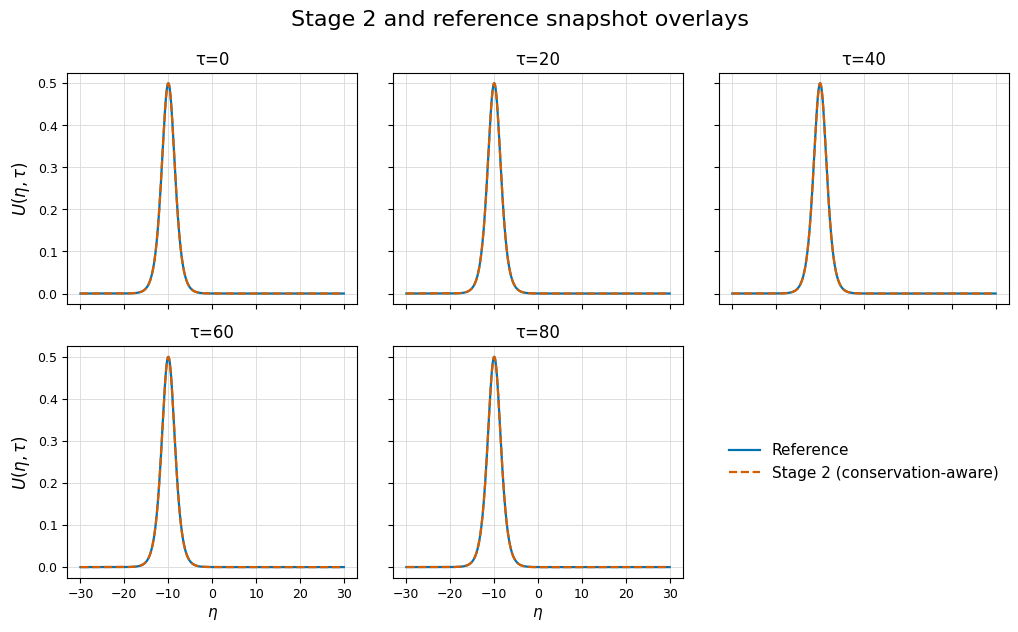

[saved][source data] Supplementary_Figure_S3_source_data.npz
[Artifact check] t=60.000 | Delta=60.000 | max|FFT-Lagrange|=8.327e-16 | relL2=2.209e-15
[Artifact check] t=80.000 | Delta=80.000 | max|FFT-Lagrange|=1.212e-07 | relL2=1.634e-07
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/colab_previews/Supplementary_Figure_S2_shift_verification_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/eps/Supplementary_Figure_S2_shift_verification.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/png/Supplementary_Figure_S2_shift_verification.png


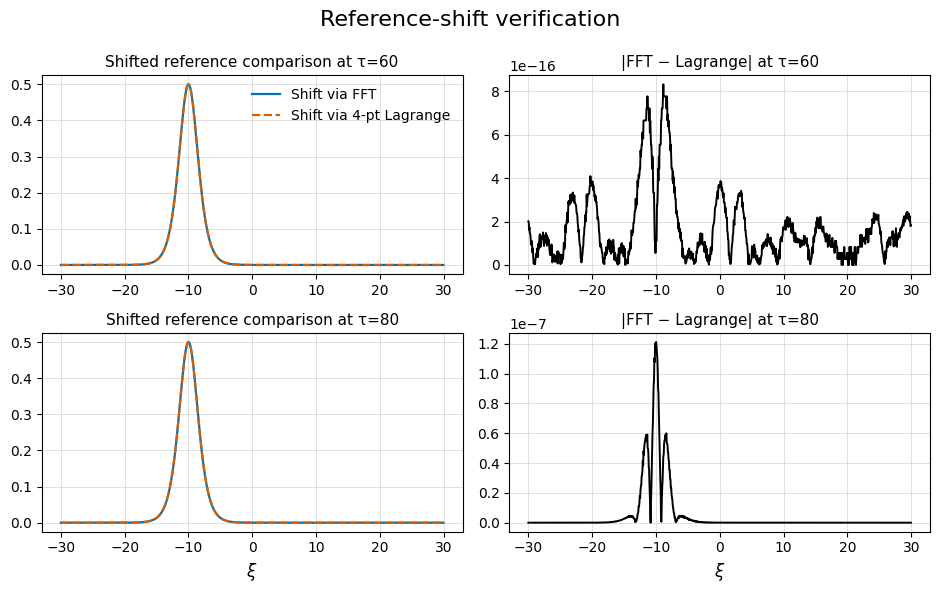

[saved][source data] Supplementary_Figure_S2_source_data.npz (contains every plotted array and reported scalar -- no re-run needed)
[loaded] residual archive: /content/drive/MyDrive/KdV_longtime_publication/data/processed/COMOV_E1_residual_diag.npz
[check] residual archive shape/finiteness validation passed (len(times)=2, len(eta)=512).
[check] Den vs |term_t|+|term_nl|+|term_disp|: max relative difference = 0.000e+00, mean = 0.000e+00
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/colab_previews/Figure6_local_PDE_balance_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/eps/Figure6_local_PDE_balance.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/png/Figure6_local_PDE_balance.png


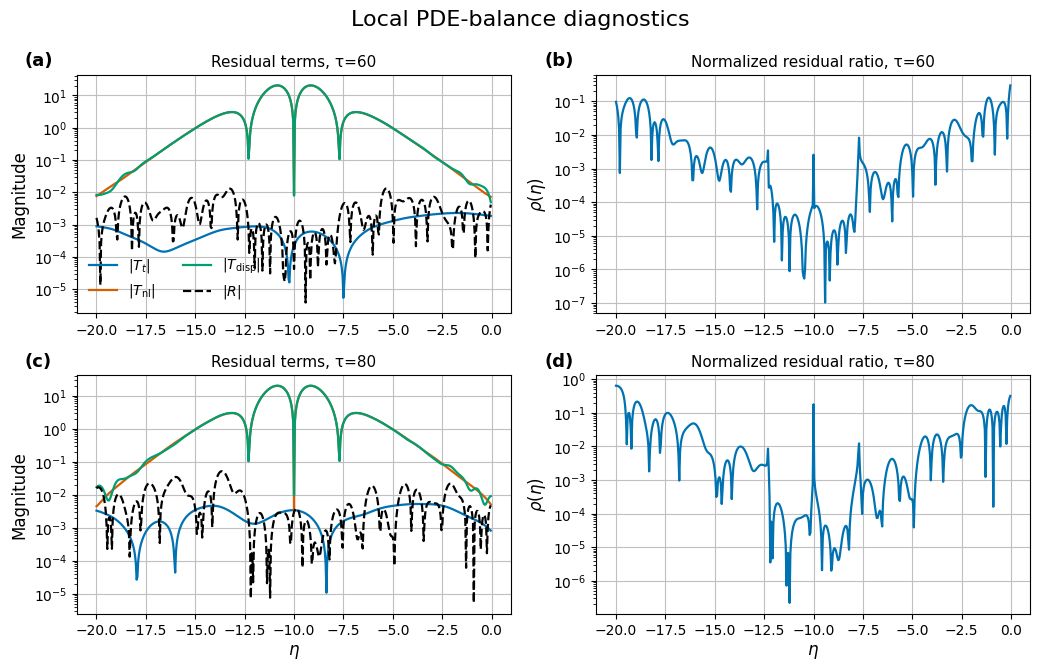

[saved][source data] /content/drive/MyDrive/KdV_longtime_publication/data/source_data/Figure6_source_data.npz
[info] Rho_masked contains NaN gaps as expected — preserved as-is.
[saved][preview] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/colab_previews/Supplementary_Figure_S1_masked_residual_colab_preview.png
[saved][publication EPS] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/eps/Supplementary_Figure_S1_masked_residual.eps
[saved][publication PNG] /content/drive/MyDrive/KdV_longtime_publication/outputs/publication_figures/supplementary/png/Supplementary_Figure_S1_masked_residual.png


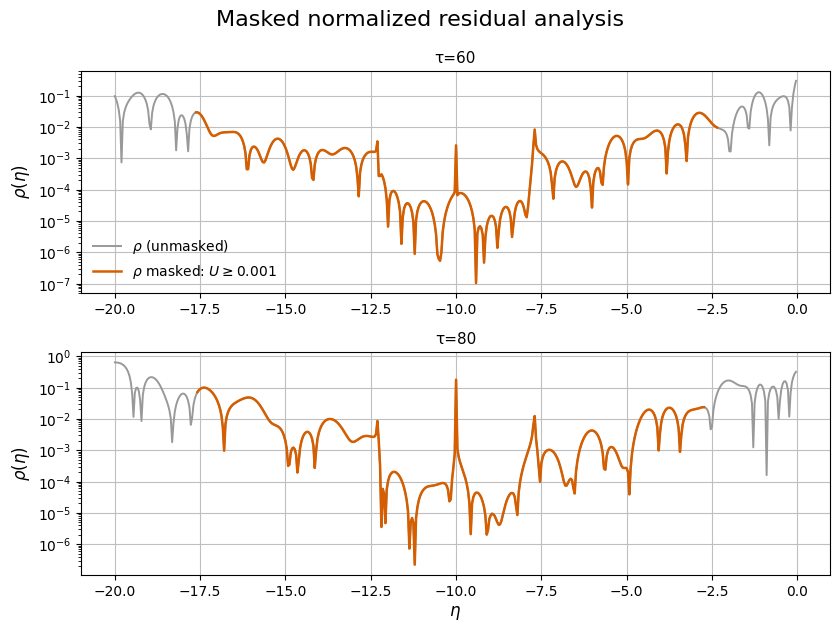

[saved][source data] /content/drive/MyDrive/KdV_longtime_publication/data/source_data/Supplementary_Figure_S1_source_data.npz

[done] Figures 2-6 and Supplementary S1-S3 generated from saved archives only.


In [5]:
# ============================================================
# FIGURES 2-6 AND SUPPLEMENTARY S1-S3
# Co-moving-frame archive + residual-diagnostic archive only.
# No numerical values are modified anywhere in this cell.
# ============================================================

import os
import csv
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.ticker import ScalarFormatter

# ------------------------------------------------------------
# 0. GATE — CONFIRMED against the co-moving training/archive cell.
#    term_nl and term_disp are defined there as:
#      term_nl   = (alpha_bar*U - V_bar)*U_e
#                = (tau_max/Xi)(alpha*U - V) U_etabar
#      term_disp = beta_bar*U_eee
#                = (tau_max/Xi^3) beta U_etabaretabareta
#    which matches the specified non-dimensional residual
#    convention exactly, confirmed by direct inspection of the
#    archive-generation source. Preserved unchanged.
# ------------------------------------------------------------
RESIDUAL_SCALING_CONFIRMED = True

if not RESIDUAL_SCALING_CONFIRMED:
    raise RuntimeError(
        "Residual scaling must be verified before generating Figure 6."
    )

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------
# PROJECT_ROOT, ARCHIVE_DIR, OUTPUT_DIR, and other paths are defined
# once in the setup cell near the top of this notebook.
PUB_ROOT = str(OUTPUT_DIR / "publication_figures")

PUB_DIRS = {
    "eps": os.path.join(PUB_ROOT, "eps"),
    "png": os.path.join(PUB_ROOT, "png"),
    "tiff": os.path.join(PUB_ROOT, "tiff"),
    "colab_preview": os.path.join(PUB_ROOT, "colab_previews"),
    # Canonical location (see setup cell): data/source_data, not a
    # subfolder of the figures output directory.
    "source_data": str(SOURCE_DATA_DIR),
    "diagnostic_panels": os.path.join(PUB_ROOT, "diagnostic_panels"),
    "supplementary_eps": os.path.join(PUB_ROOT, "supplementary", "eps"),
    "supplementary_png": os.path.join(PUB_ROOT, "supplementary", "png"),
    "supplementary_preview": os.path.join(PUB_ROOT, "supplementary", "colab_previews"),
}
for directory in PUB_DIRS.values():
    os.makedirs(directory, exist_ok=True)

# ------------------------------------------------------------
# 1b. One canonical source-data location (Section C.3 of the audit).
#     A pre-fix notebook run may have left figure source data under
#     outputs/publication_figures/source_data. Once the canonical
#     data/source_data folder holds every required file, the old
#     duplicate is renamed (never deleted) to a clearly marked backup.
#     Safe to rerun: does nothing once the backup already exists.
# ------------------------------------------------------------
_LEGACY_FIGURE_SOURCE_DATA_DIR = Path(PUB_ROOT) / "source_data"
_REQUIRED_SOURCE_DATA_FILES = {
    "Figure1_source_data.csv", "Figure2_source_data.csv",
    "Figure3_source_data.csv", "Figure4_source_data.npz",
    "Figure5_source_data.npz", "Figure6_source_data.npz",
    "Supplementary_Figure_S1_source_data.npz",
    "Supplementary_Figure_S2_source_data.npz",
    "Supplementary_Figure_S3_source_data.npz",
}
if (
    _LEGACY_FIGURE_SOURCE_DATA_DIR.resolve() != SOURCE_DATA_DIR.resolve()
    and _LEGACY_FIGURE_SOURCE_DATA_DIR.is_dir()
):
    _canonical_have = {
        p.name for p in SOURCE_DATA_DIR.glob("*") if p.is_file()
    }
    if _REQUIRED_SOURCE_DATA_FILES.issubset(_canonical_have):
        _backup_dir = (
            _LEGACY_FIGURE_SOURCE_DATA_DIR.parent
            / "source_data_legacy_backup"
        )
        if not _backup_dir.exists():
            _LEGACY_FIGURE_SOURCE_DATA_DIR.rename(_backup_dir)
            print(f"[repaired] duplicate source-data folder renamed: "
                  f"{_LEGACY_FIGURE_SOURCE_DATA_DIR} -> {_backup_dir}")
        else:
            print("[info] legacy duplicate source-data folder already "
                  "backed up; nothing to do.")
    else:
        print("[info] legacy outputs/publication_figures/source_data "
              "folder present, but canonical data/source_data is not "
              "yet fully populated -- leaving the legacy folder in "
              "place until this cell has produced every source-data "
              "file.")

SUPP_DIRS = {
    "eps": PUB_DIRS["supplementary_eps"],
    "png": PUB_DIRS["supplementary_png"],
    "colab_preview": PUB_DIRS["supplementary_preview"],
}

# ------------------------------------------------------------
# 2. Style constants (kept consistent with Cell 1)
# ------------------------------------------------------------
TITLE_FS  = 16
LABEL_FS  = 12
TICK_FS   = 10
LEGEND_FS = 10
CBAR_FS   = 10
PANEL_LABEL_FS = 13
OFFSET_FS = 10

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": TICK_FS,
    "axes.labelsize": LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEGEND_FS,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
})

COLOR_STAGE1 = "#0072B2"
COLOR_STAGE2 = "#D55E00"
STAGE_STYLE = {
    1: dict(color=COLOR_STAGE1, ls="-",  marker="o", label="Stage 1 (PDE-dominant)"),
    2: dict(color=COLOR_STAGE2, ls="--", marker="s", label="Stage 2 (conservation-aware refinement)"),
}
MARKEVERY_FRAC = 12

# ------------------------------------------------------------
# 3. Validation helpers
# ------------------------------------------------------------
def require_file(path, hint):
    if not os.path.isfile(path):
        directory = os.path.dirname(path)
        target_name = os.path.basename(path)
        near_miss = None
        if os.path.isdir(directory):
            for candidate in os.listdir(directory):
                if candidate != target_name and candidate.strip() == target_name:
                    near_miss = candidate
                    break
        if near_miss is not None:
            raise FileNotFoundError(
                f"Missing archive:\n{path}\n{hint}\n"
                f"A near-match file was found instead: {near_miss!r} "
                f"(differs only by leading/trailing whitespace in the name). "
                f"Re-run the setup cell near the top of this notebook -- it "
                f"repairs filename anomalies like this automatically -- then retry."
            )
        raise FileNotFoundError(f"Missing archive:\n{path}\n{hint}")

def require_keys(npz, keys, archive_name):
    missing = [k for k in keys if k not in npz.files]
    if missing:
        raise KeyError(
            f"Archive '{archive_name}' is missing expected key(s): {missing}. "
            f"Available keys: {list(npz.files)}"
        )

def check_finite(arr, name):
    if not np.all(np.isfinite(arr)):
        n_bad = int(np.sum(~np.isfinite(arr)))
        raise ValueError(f"Array '{name}' contains {n_bad} non-finite value(s) (NaN/Inf).")

def check_ndim(arr, name, ndim):
    if np.ndim(arr) != ndim:
        raise ValueError(f"Array '{name}' has ndim={np.ndim(arr)}, expected {ndim}.")

def check_shape(arr, expected_shape, name):
    if np.shape(arr) != tuple(expected_shape):
        raise ValueError(f"Array '{name}' has shape {np.shape(arr)}, expected {tuple(expected_shape)}.")

# ------------------------------------------------------------
# 4. Save functions — three single-purpose functions, each writes
#    exactly one artifact class. No function silently saves every
#    format regardless of why it was called.
# ------------------------------------------------------------
def save_colab_preview(fig, path, dpi=600):
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved][preview] {path}")

def save_publication_vector(fig, eps_path, png_path, dpi=600):
    fig.savefig(eps_path, format="eps", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication EPS] {eps_path}")
    fig.savefig(png_path, format="png", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication PNG] {png_path}")

def save_publication_raster(fig, png_path, tiff_path, dpi=600):
    fig.savefig(png_path, format="png", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication PNG] {png_path}")
    fig.savefig(tiff_path, format="tiff", dpi=dpi, bbox_inches="tight")
    print(f"[saved][publication TIFF] {tiff_path}")

def export_figure_vector(fig, set_title_fn, clear_title_fn, preview_path, eps_path, png_path):
    """
    1. figure already built with its Colab title (caller's responsibility)
    2. save the title-bearing Colab preview -- once
    3. clear only the notebook-style title
    4. save the publication EPS + PNG -- once
    5. restore the title
    6. plt.show() the titled version
    7. plt.close(fig)
    """
    set_title_fn()
    fig.canvas.draw()
    save_colab_preview(fig, preview_path)

    clear_title_fn()
    fig.canvas.draw()
    save_publication_vector(fig, eps_path, png_path)

    set_title_fn()
    fig.canvas.draw()
    plt.show()
    plt.close(fig)

def export_figure_raster(fig, set_title_fn, clear_title_fn, preview_path, png_path, tiff_path):
    """Same 7-step workflow as export_figure_vector, but for raster-only
    output (Figure 5's heatmap): PNG + TIFF, no EPS."""
    set_title_fn()
    fig.canvas.draw()
    save_colab_preview(fig, preview_path)

    clear_title_fn()
    fig.canvas.draw()
    save_publication_raster(fig, png_path, tiff_path)

    set_title_fn()
    fig.canvas.draw()
    plt.show()
    plt.close(fig)

def style_log_axis(ax, xlabel=None, ylabel=None):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.set_yscale("log")
    ax.grid(True, which="major", axis="both", color="0.75", linewidth=0.8)
    ax.grid(False, which="minor", axis="y")
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.yaxis.get_offset_text().set_size(OFFSET_FS)

def style_small_linear_axis(ax, xlabel=None, ylabel=None, power=-3):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=LABEL_FS)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=LABEL_FS)
    ax.grid(True, color="0.75", linewidth=0.8)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((power, power))
    ax.yaxis.set_major_formatter(formatter)
    ax.tick_params(axis="both", labelsize=TICK_FS)
    ax.yaxis.get_offset_text().set_size(OFFSET_FS)

def plot_stage_series(ax, x, y, stage, log=True, eps_offset=0.0):
    s = STAGE_STYLE[stage]
    fn = ax.semilogy if log else ax.plot
    fn(x, y + eps_offset, color=s["color"], ls=s["ls"], marker=s["marker"],
       lw=1.6, ms=4.0, markevery=max(1, len(x) // MARKEVERY_FRAC), label=s["label"])

# ============================================================
# 5. LOAD CORE ARCHIVE + explicit array-dimension validation
# ============================================================
core_path = os.path.join(ARCHIVE_DIR, "COMOV_E1_core_archive.npz")
require_file(core_path, "Run the co-moving training/archive cell first.")
D = np.load(core_path, allow_pickle=False)

CORE_KEYS = [
    "tau_ref", "xi_ref", "eta_ref", "u_ref", "U_ref", "U2",
    "relL2_stage1", "relL2_stage2",
    "crest_shift_stage1", "crest_shift_stage2",
    "dI1_stage1", "dI2_stage1", "dI3_stage1",
    "dI1_stage2", "dI2_stage2", "dI3_stage2",
    "V", "Xi", "Nx_ref",
]
require_keys(D, CORE_KEYS, "COMOV_E1_core_archive.npz")

tau_ref = D["tau_ref"]
xi_ref  = D["xi_ref"]
eta_ref = D["eta_ref"]
u_ref   = D["u_ref"]
U_ref   = D["U_ref"]
U2      = D["U2"]

# --- explicit dimensionality / shape / finiteness validation (Section 8) ---
check_ndim(tau_ref, "tau_ref", 1)
check_ndim(xi_ref, "xi_ref", 1)
check_ndim(eta_ref, "eta_ref", 1)

check_shape(U_ref, (len(tau_ref), len(eta_ref)), "U_ref")
check_shape(U2, (len(tau_ref), len(eta_ref)), "U2")
check_shape(u_ref, (len(tau_ref), len(xi_ref)), "u_ref")

for name, arr in [("tau_ref", tau_ref), ("xi_ref", xi_ref), ("eta_ref", eta_ref),
                   ("u_ref", u_ref), ("U_ref", U_ref), ("U2", U2)]:
    check_finite(arr, name)

relL2_stage1 = D["relL2_stage1"]; relL2_stage2 = D["relL2_stage2"]
crest_shift_stage1 = D["crest_shift_stage1"]; crest_shift_stage2 = D["crest_shift_stage2"]
dI1_stage1 = D["dI1_stage1"]; dI2_stage1 = D["dI2_stage1"]; dI3_stage1 = D["dI3_stage1"]
dI1_stage2 = D["dI1_stage2"]; dI2_stage2 = D["dI2_stage2"]; dI3_stage2 = D["dI3_stage2"]

for name, arr in [
    ("relL2_stage1", relL2_stage1), ("relL2_stage2", relL2_stage2),
    ("crest_shift_stage1", crest_shift_stage1), ("crest_shift_stage2", crest_shift_stage2),
    ("dI1_stage1", dI1_stage1), ("dI2_stage1", dI2_stage1), ("dI3_stage1", dI3_stage1),
    ("dI1_stage2", dI1_stage2), ("dI2_stage2", dI2_stage2), ("dI3_stage2", dI3_stage2),
]:
    check_ndim(arr, name, 1)
    check_shape(arr, (len(tau_ref),), name)
    check_finite(arr, name)

V = float(np.asarray(D["V"]).reshape(-1)[0])
Xi = float(np.asarray(D["Xi"]).reshape(-1)[0])
Nx_ref = int(np.asarray(D["Nx_ref"]).reshape(-1)[0])

print("[loaded] core archive:", core_path)
print("[check] core archive dimension/shape/finiteness validation passed.")

abs_err_stage2 = np.abs(U2 - U_ref)

# ============================================================
# 6. FIGURE 2 — relative L2 error (co-moving)
# ============================================================
fig2, ax2 = plt.subplots(figsize=(6.0, 4.2))
plot_stage_series(ax2, tau_ref, relL2_stage1, 1)
plot_stage_series(ax2, tau_ref, relL2_stage2, 2)
style_log_axis(ax2, xlabel=r"$\tau$", ylabel=r"Relative $L^2$ error (co-moving)")
ax2.legend(fontsize=LEGEND_FS, frameon=False)

TITLE_2 = "Co-moving relative L2 error"
def set_t2(): ax2.set_title(TITLE_2, fontsize=TITLE_FS)
def clear_t2(): ax2.set_title("")

fig2.tight_layout()

preview_path_2 = os.path.join(PUB_DIRS["colab_preview"], "Figure2_comoving_relative_L2_colab_preview.png")
eps_path_2 = os.path.join(PUB_DIRS["eps"], "Figure2_comoving_relative_L2.eps")
png_path_2 = os.path.join(PUB_DIRS["png"], "Figure2_comoving_relative_L2.png")
export_figure_vector(fig2, set_t2, clear_t2, preview_path_2, eps_path_2, png_path_2)

with open(os.path.join(PUB_DIRS["source_data"], "Figure2_source_data.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["tau", "relL2_stage1", "relL2_stage2"])
    for row in zip(tau_ref, relL2_stage1, relL2_stage2):
        w.writerow(row)
print("[saved][source data] Figure2_source_data.csv")

# ============================================================
# 7. FIGURE 3 — crest-drift magnitude (co-moving)
#    epsilon_plot is a PLOTTING OFFSET ONLY (log-axis floor),
#    not a physical error contribution.
# ============================================================
epsilon_plot = 1e-12

fig3, ax3 = plt.subplots(figsize=(6.0, 4.2))
plot_stage_series(ax3, tau_ref, np.abs(crest_shift_stage1), 1, eps_offset=epsilon_plot)
plot_stage_series(ax3, tau_ref, np.abs(crest_shift_stage2), 2, eps_offset=epsilon_plot)
style_log_axis(ax3, xlabel=r"$\tau$",
               ylabel=r"$|\eta_{\max}^{\mathrm{PINN}}-\eta_{\max}^{\mathrm{ref}}|+\varepsilon_{\mathrm{plot}}$")
ax3.legend(fontsize=LEGEND_FS, frameon=False)

TITLE_3 = "Co-moving crest drift"
def set_t3(): ax3.set_title(TITLE_3, fontsize=TITLE_FS)
def clear_t3(): ax3.set_title("")

fig3.tight_layout()

preview_path_3 = os.path.join(PUB_DIRS["colab_preview"], "Figure3_comoving_crest_drift_colab_preview.png")
eps_path_3 = os.path.join(PUB_DIRS["eps"], "Figure3_comoving_crest_drift.eps")
png_path_3 = os.path.join(PUB_DIRS["png"], "Figure3_comoving_crest_drift.png")
export_figure_vector(fig3, set_t3, clear_t3, preview_path_3, eps_path_3, png_path_3)

with open(os.path.join(PUB_DIRS["source_data"], "Figure3_source_data.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["tau", "crest_shift_stage1", "crest_shift_stage2"])
    for row in zip(tau_ref, crest_shift_stage1, crest_shift_stage2):
        w.writerow(row)
print("[saved][source data] Figure3_source_data.csv")

# ============================================================
# 8. FIGURE 4 — invariant drift, 2-panel vertical (Stage 1 / Stage 2)
#    Manuscript notation: delta I1 (mass), delta I2 (L2-type), delta H
#    (Hamiltonian) — dI3_* archive arrays are labelled delta H here.
# ============================================================
fig4, (ax4a, ax4b) = plt.subplots(2, 1, figsize=(6.0, 7.5), sharex=True)

ax4a.plot(tau_ref, dI1_stage1, color="#0072B2", lw=1.6, label=r"$\delta I_1$ (mass)")
ax4a.plot(tau_ref, dI2_stage1, color="#D55E00", lw=1.6, label=r"$\delta I_2$ ($L^2$-type)")
ax4a.plot(tau_ref, dI3_stage1, color="#009E73", lw=1.6, label=r"$\delta H$ (Hamiltonian)")
style_small_linear_axis(ax4a, ylabel="Relative drift (Stage 1)", power=-3)
ax4a.legend(fontsize=LEGEND_FS, frameon=False)
ax4a.text(-0.10, 1.02, "(a)", transform=ax4a.transAxes,
          fontsize=PANEL_LABEL_FS, fontweight="bold", va="bottom")
print(f"[check] max |Stage 1 invariant drift| = "
      f"{np.max(np.abs(np.stack([dI1_stage1, dI2_stage1, dI3_stage1]))):.3e} "
      f"(axis display uses a fixed power of 1e-3 for readability; "
      f"ScalarFormatter power limits do not clip plotted values)")

ax4b.plot(tau_ref, dI1_stage2, color="#0072B2", lw=1.6, label=r"$\delta I_1$ (mass)")
ax4b.plot(tau_ref, dI2_stage2, color="#D55E00", lw=1.6, label=r"$\delta I_2$ ($L^2$-type)")
ax4b.plot(tau_ref, dI3_stage2, color="#009E73", lw=1.6, label=r"$\delta H$ (Hamiltonian)")
style_small_linear_axis(ax4b, xlabel=r"$\tau$", ylabel="Relative drift (Stage 2)", power=-4)
ax4b.legend(fontsize=LEGEND_FS, frameon=False)
ax4b.text(-0.10, 1.02, "(b)", transform=ax4b.transAxes,
          fontsize=PANEL_LABEL_FS, fontweight="bold", va="bottom")
print(f"[check] max |Stage 2 invariant drift| = "
      f"{np.max(np.abs(np.stack([dI1_stage2, dI2_stage2, dI3_stage2]))):.3e} "
      f"(axis display uses a fixed power of 1e-4 for readability; "
      f"ScalarFormatter power limits do not clip plotted values)")

TITLE_4 = "Invariant drift in the co-moving frame"
def set_t4(): fig4.suptitle(TITLE_4, fontsize=TITLE_FS)
def clear_t4():
    if fig4._suptitle is not None:
        fig4._suptitle.set_text("")

fig4.tight_layout(rect=[0, 0, 1, 0.96])

preview_path_4 = os.path.join(PUB_DIRS["colab_preview"], "Figure4_invariant_drift_colab_preview.png")
eps_path_4 = os.path.join(PUB_DIRS["eps"], "Figure4_invariant_drift.eps")
png_path_4 = os.path.join(PUB_DIRS["png"], "Figure4_invariant_drift.png")
export_figure_vector(fig4, set_t4, clear_t4, preview_path_4, eps_path_4, png_path_4)

np.savez_compressed(
    os.path.join(PUB_DIRS["source_data"], "Figure4_source_data.npz"),
    tau=tau_ref,
    dI1_stage1=dI1_stage1, dI2_stage1=dI2_stage1, dH_stage1=dI3_stage1,
    dI1_stage2=dI1_stage2, dI2_stage2=dI2_stage2, dH_stage2=dI3_stage2,
)
print("[saved][source data] Figure4_source_data.npz")

# ============================================================
# 9. FIGURE 5 — space-time absolute error heatmap (raster: PNG + TIFF)
# ============================================================
fig5, ax5 = plt.subplots(figsize=(6.0, 4.8))
im = ax5.imshow(
    abs_err_stage2,
    aspect="auto",
    origin="lower",
    extent=[eta_ref[0], eta_ref[-1], tau_ref[0], tau_ref[-1]],
)
ax5.set_xlabel(r"$\eta$", fontsize=LABEL_FS)
ax5.set_ylabel(r"$\tau$", fontsize=LABEL_FS)
ax5.tick_params(axis="both", labelsize=TICK_FS)

cbar = fig5.colorbar(im, ax=ax5)
cbar.set_label(r"$|U_{\mathrm{Stage\,2}}-U_{\mathrm{ref}}|$", fontsize=CBAR_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
cb_formatter = ScalarFormatter(useMathText=True)
cb_formatter.set_scientific(True)
cb_formatter.set_powerlimits((-4, -4))
cbar.formatter = cb_formatter
cbar.update_ticks()
cbar.ax.yaxis.get_offset_text().set_size(OFFSET_FS)

TITLE_5 = "Stage 2 space-time absolute error"
def set_t5(): ax5.set_title(TITLE_5, fontsize=TITLE_FS)
def clear_t5(): ax5.set_title("")

fig5.tight_layout()

preview_path_5 = os.path.join(PUB_DIRS["colab_preview"], "Figure5_spacetime_absolute_error_colab_preview.png")
png_path_5 = os.path.join(PUB_DIRS["png"], "Figure5_spacetime_absolute_error.png")
tiff_path_5 = os.path.join(PUB_DIRS["tiff"], "Figure5_spacetime_absolute_error.tiff")
export_figure_raster(fig5, set_t5, clear_t5, preview_path_5, png_path_5, tiff_path_5)

np.savez_compressed(
    os.path.join(PUB_DIRS["source_data"], "Figure5_source_data.npz"),
    tau=tau_ref, eta=eta_ref, abs_err_stage2=abs_err_stage2,
)
print("[saved][source data] Figure5_source_data.npz")

# ============================================================
# 10. SUPPLEMENTARY FIGURE S3 — reference vs Stage-2 snapshots
#     2x3 grid: 5 data panels (tau=0,20,40,60,80) + 1 shared-legend panel.
#     Routed to the supplementary directories (SUPP_DIRS), not main.
# ============================================================
sel_times = [0.0, 20.0, 40.0, 60.0, 80.0]
sel_idx = [int(np.argmin(np.abs(tau_ref - t))) for t in sel_times]

figS3, axesS3_grid = plt.subplots(2, 3, figsize=(10.5, 6.4), sharex=True, sharey=True)
axesS3_flat = axesS3_grid.flatten()
data_axes_S3 = axesS3_flat[:5]
legend_ax_S3 = axesS3_flat[5]

panel_titles_S3 = [f"τ={tau_ref[i]:.0f}" for i in sel_idx]
ref_line = lag_line = None
for ax, i, ptitle in zip(data_axes_S3, sel_idx, panel_titles_S3):
    ref_line, = ax.plot(eta_ref, U_ref[i], color="#0072B2", lw=1.6, label="Reference")
    lag_line, = ax.plot(eta_ref, U2[i], color="#D55E00", ls="--", lw=1.6, label="Stage 2 (conservation-aware)")
    ax.grid(True, color="0.85", linewidth=0.6)
    ax.tick_params(axis="both", labelsize=TICK_FS - 1)
    # Per-panel time annotation is a scientific annotation (identifies which
    # tau each panel shows) and is retained in the publication export too.
    ax.set_title(ptitle, fontsize=LABEL_FS)

for ax in axesS3_grid[-1, :]:
    ax.set_xlabel(r"$\eta$", fontsize=LABEL_FS - 1)
for ax in axesS3_grid[:, 0]:
    ax.set_ylabel(r"$U(\eta,\tau)$", fontsize=LABEL_FS)

# Sixth panel: shared legend only (2 entries total, not 10 overlapping ones).
legend_ax_S3.axis("off")
legend_ax_S3.legend(
    handles=[ref_line, lag_line], labels=["Reference", "Stage 2 (conservation-aware)"],
    loc="center", fontsize=LEGEND_FS + 1, frameon=False,
)

NOTEBOOK_TITLE_S3 = "Stage 2 and reference snapshot overlays"
def set_tS3():
    figS3.suptitle(NOTEBOOK_TITLE_S3, fontsize=TITLE_FS)
def clear_tS3():
    if figS3._suptitle is not None:
        figS3._suptitle.set_text("")

figS3.tight_layout(rect=[0, 0, 1, 0.94])

preview_path_S3 = os.path.join(SUPP_DIRS["colab_preview"], "Supplementary_Figure_S3_snapshot_overlays_colab_preview.png")
eps_path_S3 = os.path.join(SUPP_DIRS["eps"], "Supplementary_Figure_S3_snapshot_overlays.eps")
png_path_S3 = os.path.join(SUPP_DIRS["png"], "Supplementary_Figure_S3_snapshot_overlays.png")
export_figure_vector(figS3, set_tS3, clear_tS3, preview_path_S3, eps_path_S3, png_path_S3)

np.savez_compressed(
    os.path.join(PUB_DIRS["source_data"], "Supplementary_Figure_S3_source_data.npz"),
    tau_selected=np.array([tau_ref[i] for i in sel_idx]),
    eta=eta_ref,
    U_ref_selected=np.stack([U_ref[i] for i in sel_idx]),
    U2_selected=np.stack([U2[i] for i in sel_idx]),
)
print("[saved][source data] Supplementary_Figure_S3_source_data.npz")

# ============================================================
# 11. SUPPLEMENTARY FIGURE S2 — FFT vs 4-pt Lagrange shift check
#     Routed to the supplementary directories (SUPP_DIRS), not main.
#     Source-data archive stores every plotted array, not just inputs.
# ============================================================
dx = (2.0 * Xi) / Nx_ref
k_ref = 2.0 * np.pi * np.fft.fftfreq(Nx_ref, d=dx)

def spectral_shift_periodic_local(u_x, Delta):
    uh = np.fft.fft(u_x)
    return np.fft.ifft(uh * np.exp(1j * k_ref * Delta)).real

def shift_periodic_lagrange4(u_x, Delta):
    s = Delta / dx
    N = u_x.size
    i = np.arange(N)
    j = i + s
    base = np.floor(j).astype(int)
    frac = j - base

    def U(idx):
        return u_x[np.mod(idx, N)]

    u_m1 = U(base - 1); u_0 = U(base); u_p1 = U(base + 1); u_p2 = U(base + 2)
    x = frac
    Lm1 = -x * (x - 1) * (x - 2) / 6.0
    L0 = (x + 1) * (x - 1) * (x - 2) / 2.0
    L1 = -(x + 1) * x * (x - 2) / 2.0
    L2 = (x + 1) * x * (x - 1) / 6.0
    return Lm1 * u_m1 + L0 * u_0 + L1 * u_p1 + L2 * u_p2

test_times = [60.0, 80.0]
test_idx = [int(np.argmin(np.abs(tau_ref - t))) for t in test_times]
actual_test_times = [float(tau_ref[it]) for it in test_idx]

figS2, axesS2 = plt.subplots(2, 2, figsize=(9.5, 6.0))

# Dynamically-keyed dictionary of every plotted array + reported scalar,
# so Supplementary Figure S2 is fully reproducible from disk with no
# re-running of the FFT or interpolation operations. Keys are built from
# the actual sampled tau values (rounded to nearest integer), not
# hard-coded, so they stay correct even if the archive's time grid ever
# selects slightly different reporting times.
shift_source = {
    "xi": xi_ref,
    "test_times": np.asarray(actual_test_times),
    "V": np.asarray([V]),
}

for row, (t_target, it) in enumerate(zip(test_times, test_idx)):
    t = actual_test_times[row]
    tkey = f"tau{int(round(t))}"
    Delta = float(V * t)

    u = u_ref[it].astype(np.float64, copy=False)
    U_fft = spectral_shift_periodic_local(u, Delta)
    U_lag = shift_periodic_lagrange4(u, Delta)
    diff = U_fft - U_lag
    max_abs = float(np.max(np.abs(diff)))
    rel_l2 = float(np.linalg.norm(diff) / (np.linalg.norm(U_fft) + 1e-12))

    print(f"[Artifact check] t={t:.3f} | Delta={Delta:.3f} | "
          f"max|FFT-Lagrange|={max_abs:.3e} | relL2={rel_l2:.3e}")

    shift_source[f"U_fft_{tkey}"] = U_fft
    shift_source[f"U_lagrange_{tkey}"] = U_lag
    shift_source[f"signed_difference_{tkey}"] = diff
    shift_source[f"abs_difference_{tkey}"] = np.abs(diff)
    shift_source[f"max_abs_difference_{tkey}"] = np.asarray([max_abs])
    shift_source[f"relative_L2_difference_{tkey}"] = np.asarray([rel_l2])

    axesS2[row, 0].plot(xi_ref, U_fft, color="#0072B2", lw=1.6, label="Shift via FFT")
    axesS2[row, 0].plot(xi_ref, U_lag, color="#D55E00", ls="--", lw=1.6, label="Shift via 4-pt Lagrange")
    axesS2[row, 0].grid(True, color="0.85", linewidth=0.6)
    axesS2[row, 0].tick_params(axis="both", labelsize=TICK_FS)
    axesS2[row, 0].set_title(f"Shifted reference comparison at τ={t:.0f}", fontsize=LABEL_FS - 1)

    axesS2[row, 1].plot(xi_ref, np.abs(diff), color="black", lw=1.4)
    axesS2[row, 1].grid(True, color="0.85", linewidth=0.6)
    axesS2[row, 1].tick_params(axis="both", labelsize=TICK_FS)
    axesS2[row, 1].set_title(f"|FFT − Lagrange| at τ={t:.0f}", fontsize=LABEL_FS - 1)

axesS2[0, 0].legend(fontsize=LEGEND_FS, frameon=False)
for ax in axesS2[-1, :]:
    ax.set_xlabel(r"$\xi$", fontsize=LABEL_FS)

NOTEBOOK_TITLE_S2 = "Reference-shift verification"
def set_tS2():
    figS2.suptitle(NOTEBOOK_TITLE_S2, fontsize=TITLE_FS)
def clear_tS2():
    if figS2._suptitle is not None:
        figS2._suptitle.set_text("")

figS2.tight_layout(rect=[0, 0, 1, 0.93])

preview_path_S2 = os.path.join(SUPP_DIRS["colab_preview"], "Supplementary_Figure_S2_shift_verification_colab_preview.png")
eps_path_S2 = os.path.join(SUPP_DIRS["eps"], "Supplementary_Figure_S2_shift_verification.eps")
png_path_S2 = os.path.join(SUPP_DIRS["png"], "Supplementary_Figure_S2_shift_verification.png")
export_figure_vector(figS2, set_tS2, clear_tS2, preview_path_S2, eps_path_S2, png_path_S2)

np.savez_compressed(
    os.path.join(PUB_DIRS["source_data"], "Supplementary_Figure_S2_source_data.npz"),
    **shift_source,
)
print("[saved][source data] Supplementary_Figure_S2_source_data.npz "
      "(contains every plotted array and reported scalar -- no re-run needed)")

# ============================================================
# 12. LOAD RESIDUAL DIAGNOSTICS ARCHIVE + explicit shape validation
# ============================================================
res_path = os.path.join(ARCHIVE_DIR, "COMOV_E1_residual_diag.npz")
require_file(res_path, "Run the co-moving training/archive cell first "
                        "(it saves this archive automatically).")
RES = np.load(res_path, allow_pickle=False)

RES_BASE_KEYS = [
    "times", "eta", "U", "Rabs", "Den", "Rho",
    "Rho_masked", "U_min",
]
require_keys(RES, RES_BASE_KEYS, "COMOV_E1_residual_diag.npz")

times = RES["times"]
eta = RES["eta"]

# Current archives use explicit magnitude names. Legacy archives from the
# research notebook used term_t/term_nl/term_disp for the same magnitudes.
if all(
    key in RES.files
    for key in (
        "term_t_magnitude",
        "term_nl_magnitude",
        "term_disp_magnitude",
    )
):
    term_t = RES["term_t_magnitude"]
    term_nl = RES["term_nl_magnitude"]
    term_disp = RES["term_disp_magnitude"]
elif all(
    key in RES.files
    for key in ("term_t", "term_nl", "term_disp")
):
    warnings.warn(
        "Loading legacy residual keys term_t/term_nl/term_disp. "
        "These arrays contain magnitudes, not signed terms."
    )
    term_t = RES["term_t"]
    term_nl = RES["term_nl"]
    term_disp = RES["term_disp"]
else:
    raise KeyError(
        "Residual archive must contain either the explicit magnitude "
        "keys or the legacy term_t/term_nl/term_disp keys."
    )

Rabs = RES["Rabs"]
Den = RES["Den"]
Rho = RES["Rho"]
Rho_masked = RES["Rho_masked"]
U_min = float(np.asarray(RES["U_min"]).reshape(-1)[0])

if len(times) != 2:
    raise ValueError(
        "Figure 6 and Supplementary Figure S1 require exactly two residual reporting times."
    )

expected_shape = (len(times), len(eta))
for name, arr in [("term_t", term_t), ("term_nl", term_nl), ("term_disp", term_disp),
                   ("Rabs", Rabs), ("Den", Den), ("Rho", Rho), ("Rho_masked", Rho_masked)]:
    check_shape(arr, expected_shape, name)

for name, arr in [("term_t", term_t), ("term_nl", term_nl), ("term_disp", term_disp),
                   ("Rabs", Rabs), ("Den", Den), ("Rho", Rho)]:
    check_finite(arr, name)

# Rho_masked intentionally contains NaN in masked-out regions. Only the
# non-NaN entries are required to be finite; NaNs are never replaced
# with epsilon.
valid = ~np.isnan(Rho_masked)
if not np.all(np.isfinite(Rho_masked[valid])):
    raise ValueError("Rho_masked contains non-finite values outside of the intentional NaN mask.")

print("[loaded] residual archive:", res_path)
print("[check] residual archive shape/finiteness validation passed "
      f"(len(times)={len(times)}, len(eta)={len(eta)}).")

# ------------------------------------------------------------
# One-time self-healing migration: if this archive was loaded through
# the legacy term_t/term_nl/term_disp keys, rewrite it in place using
# the current explicit magnitude key names, so the "legacy residual
# keys" warning above does not recur on the next run. All other keys
# and values are preserved byte-for-byte; only the three key names
# change.
# ------------------------------------------------------------
_used_legacy_keys = all(
    key in RES.files for key in ("term_t", "term_nl", "term_disp")
) and not all(
    key in RES.files
    for key in ("term_t_magnitude", "term_nl_magnitude", "term_disp_magnitude")
)
if _used_legacy_keys:
    _migrated_arrays = {
        key: RES[key] for key in RES.files
        if key not in ("term_t", "term_nl", "term_disp")
    }
    _migrated_arrays["term_t_magnitude"] = term_t
    _migrated_arrays["term_nl_magnitude"] = term_nl
    _migrated_arrays["term_disp_magnitude"] = term_disp
    RES.close()

    # Backup before replacement (Section C.2). Idempotent: if a backup
    # from an earlier run already exists, it is left untouched rather
    # than overwritten, and the migration still proceeds.
    _res_backup_path = res_path.replace(".npz", "_prekey_migration_backup.npz")
    if not os.path.isfile(_res_backup_path):
        import shutil as _shutil
        _shutil.copy2(res_path, _res_backup_path)
        print(f"[backup] {res_path} -> {_res_backup_path}")
    else:
        print(f"[info] backup already exists, not overwritten: {_res_backup_path}")

    np.savez_compressed(res_path, **_migrated_arrays)

    # Verify the newly written archive before trusting it: every key
    # and array must round-trip exactly (values, shapes, and dtypes).
    with np.load(res_path, allow_pickle=False) as _RES_check:
        for _key, _expected in _migrated_arrays.items():
            if _key not in _RES_check.files:
                raise RuntimeError(
                    f"Residual-archive migration verification failed: "
                    f"key {_key!r} missing after rewrite."
                )
            _actual = _RES_check[_key]
            if _actual.shape != np.asarray(_expected).shape or _actual.dtype != np.asarray(_expected).dtype:
                raise RuntimeError(
                    f"Residual-archive migration verification failed for "
                    f"key {_key!r}: shape/dtype mismatch after rewrite."
                )
            if not np.array_equal(_actual, np.asarray(_expected), equal_nan=True):
                raise RuntimeError(
                    f"Residual-archive migration verification failed for "
                    f"key {_key!r}: values changed during rewrite."
                )
    print(f"[repaired] {res_path} rewritten with current key names "
          f"(term_t_magnitude/term_nl_magnitude/term_disp_magnitude) and "
          f"verified byte-for-byte -- this warning will not appear again.")
else:
    RES.close()

# ------------------------------------------------------------
# Internal consistency check on Den (does NOT verify coordinate
# scaling, only self-consistency of the denominator). Preserved
# exactly as required.
# ------------------------------------------------------------
Den_reconstructed = np.abs(term_t) + np.abs(term_nl) + np.abs(term_disp)
den_rel_diff = np.abs(Den - Den_reconstructed) / (np.abs(Den_reconstructed) + 1e-30)
print(f"[check] Den vs |term_t|+|term_nl|+|term_disp|: "
      f"max relative difference = {np.max(den_rel_diff):.3e}, "
      f"mean = {np.mean(den_rel_diff):.3e}")

# ============================================================
# 13. FIGURE 6 — local PDE-balance diagnostics
# ============================================================
number_of_residual_times = len(times)

fig6, axes6 = plt.subplots(
    number_of_residual_times,
    2,
    figsize=(
        10.5,
        3.4 * number_of_residual_times,
    ),
    squeeze=False,
)

panel_letters = [
    "(a)",
    "(b)",
    "(c)",
    "(d)",
]

panel_index = 0

for row, time in enumerate(times):
    magnitude_axis = axes6[row, 0]

    magnitude_axis.semilogy(
        eta,
        np.abs(term_t[row]) + 1e-30,
        color="#0072B2",
        lw=1.6,
        label=r"$|T_t|$",
    )
    magnitude_axis.semilogy(
        eta,
        np.abs(term_nl[row]) + 1e-30,
        color="#D55E00",
        lw=1.6,
        label=r"$|T_{\mathrm{nl}}|$",
    )
    magnitude_axis.semilogy(
        eta,
        np.abs(term_disp[row]) + 1e-30,
        color="#009E73",
        lw=1.6,
        label=r"$|T_{\mathrm{disp}}|$",
    )
    magnitude_axis.semilogy(
        eta,
        Rabs[row] + 1e-30,
        color="black",
        ls="--",
        lw=1.6,
        label=r"$|R|$",
    )

    style_log_axis(
        magnitude_axis,
        ylabel="Magnitude",
    )

    magnitude_axis.text(
        -0.12,
        1.02,
        panel_letters[panel_index],
        transform=magnitude_axis.transAxes,
        fontsize=PANEL_LABEL_FS,
        fontweight="bold",
        va="bottom",
    )
    panel_index += 1

    ratio_axis = axes6[row, 1]

    ratio_axis.semilogy(
        eta,
        Rho[row] + 1e-30,
        color="#0072B2",
        lw=1.6,
    )

    style_log_axis(
        ratio_axis,
        ylabel=r"$\rho(\eta)$",
    )

    ratio_axis.text(
        -0.12,
        1.02,
        panel_letters[panel_index],
        transform=ratio_axis.transAxes,
        fontsize=PANEL_LABEL_FS,
        fontweight="bold",
        va="bottom",
    )
    panel_index += 1

axes6[0, 0].legend(
    fontsize=LEGEND_FS,
    ncol=2,
    frameon=False,
)

for ax in axes6[-1, :]:
    ax.set_xlabel(
        r"$\eta$",
        fontsize=LABEL_FS,
    )

NOTEBOOK_TITLE_6 = (
    "Local PDE-balance diagnostics"
)

panel_time_titles = []

for time in times:
    panel_time_titles.append(
        f"Residual terms, τ={float(time):.0f}"
    )
    panel_time_titles.append(
        (
            "Normalized residual ratio, "
            f"τ={float(time):.0f}"
        )
    )


def set_t6():
    fig6.suptitle(
        NOTEBOOK_TITLE_6,
        fontsize=TITLE_FS,
    )

    for ax, panel_title in zip(
        axes6.flat,
        panel_time_titles,
    ):
        ax.set_title(
            panel_title,
            fontsize=LABEL_FS - 1,
        )


def clear_t6():
    if fig6._suptitle is not None:
        fig6._suptitle.set_text("")


fig6.tight_layout(
    rect=[0, 0, 1, 0.94]
)

preview_path_6 = os.path.join(
    PUB_DIRS["colab_preview"],
    "Figure6_local_PDE_balance_colab_preview.png",
)
eps_path_6 = os.path.join(
    PUB_DIRS["eps"],
    "Figure6_local_PDE_balance.eps",
)
png_path_6 = os.path.join(
    PUB_DIRS["png"],
    "Figure6_local_PDE_balance.png",
)

export_figure_vector(
    fig6,
    set_t6,
    clear_t6,
    preview_path_6,
    eps_path_6,
    png_path_6,
)

figure6_source_path = os.path.join(
    PUB_DIRS["source_data"],
    "Figure6_source_data.npz",
)

np.savez_compressed(
    figure6_source_path,
    times=times,
    eta=eta,
    term_t_magnitude=np.abs(term_t),
    term_nl_magnitude=np.abs(term_nl),
    term_disp_magnitude=np.abs(term_disp),
    residual_magnitude=Rabs,
    normalization_denominator=Den,
    normalized_residual_ratio=Rho,
)

print(
    f"[saved][source data] "
    f"{figure6_source_path}"
)

# ============================================================
# 14. SUPPLEMENTARY FIGURE S1 — masked residual ratio
# ============================================================
Rho_masked_safe = np.array(
    Rho_masked,
    dtype=float,
    copy=True,
)

if np.any(
    np.isnan(Rho_masked_safe)
):
    print(
        "[info] Rho_masked contains NaN gaps "
        "as expected — preserved as-is."
    )
else:
    warnings.warn(
        "Rho_masked contains no NaN values. "
        "If masked-out points were stored as 0 "
        "or epsilon rather than NaN, they may "
        "misleadingly appear as low-residual data."
    )

figS1, axesS1 = plt.subplots(
    number_of_residual_times,
    1,
    figsize=(
        8.5,
        3.2 * number_of_residual_times,
    ),
    squeeze=False,
)

axesS1 = axesS1[:, 0]

for row, time in enumerate(times):
    axis = axesS1[row]

    axis.semilogy(
        eta,
        Rho[row] + 1e-30,
        color="0.6",
        lw=1.4,
        label=r"$\rho$ (unmasked)",
    )

    axis.semilogy(
        eta,
        Rho_masked_safe[row] + 1e-30,
        color="#D55E00",
        lw=1.8,
        label=(
            rf"$\rho$ masked: "
            rf"$U\geq {U_min:g}$"
        ),
    )

    style_log_axis(
        axis,
        ylabel=r"$\rho(\eta)$",
    )

    axis.set_title(
        f"τ={float(time):.0f}",
        fontsize=LABEL_FS - 1,
    )

axesS1[0].legend(
    fontsize=LEGEND_FS,
    frameon=False,
)

axesS1[-1].set_xlabel(
    r"$\eta$",
    fontsize=LABEL_FS,
)

NOTEBOOK_TITLE_S1 = (
    "Masked normalized residual analysis"
)


def set_tS1():
    figS1.suptitle(
        NOTEBOOK_TITLE_S1,
        fontsize=TITLE_FS,
    )


def clear_tS1():
    if figS1._suptitle is not None:
        figS1._suptitle.set_text("")


figS1.tight_layout(
    rect=[0, 0, 1, 0.94]
)

preview_path_S1 = os.path.join(
    SUPP_DIRS["colab_preview"],
    (
        "Supplementary_Figure_S1_"
        "masked_residual_colab_preview.png"
    ),
)
eps_path_S1 = os.path.join(
    SUPP_DIRS["eps"],
    (
        "Supplementary_Figure_S1_"
        "masked_residual.eps"
    ),
)
png_path_S1 = os.path.join(
    SUPP_DIRS["png"],
    (
        "Supplementary_Figure_S1_"
        "masked_residual.png"
    ),
)

export_figure_vector(
    figS1,
    set_tS1,
    clear_tS1,
    preview_path_S1,
    eps_path_S1,
    png_path_S1,
)

supplementary_s1_source_path = os.path.join(
    PUB_DIRS["source_data"],
    (
        "Supplementary_Figure_S1_"
        "source_data.npz"
    ),
)

np.savez_compressed(
    supplementary_s1_source_path,
    times=times,
    eta=eta,
    Rho=Rho,
    Rho_masked=Rho_masked_safe,
    U_min=U_min,
)

print(
    f"[saved][source data] "
    f"{supplementary_s1_source_path}"
)

print(
    "\n[done] Figures 2-6 and Supplementary "
    "S1-S3 generated from saved archives only."
)

## Build the release manifest and verify headline metrics

Run the following cell after the publication-figure cells. It creates:

- `release/MANIFEST.csv`;
- `release/SHA256SUMS.txt`;
- `release/summary_metrics.csv`.

The manifest and checksums should be included in the Zenodo Dataset record.

In [6]:
# ============================================================
# RELEASE MANIFEST, CHECKSUMS, AND HEADLINE METRICS
# ============================================================

PUB_ROOT = OUTPUT_DIR / "publication_figures"
# Canonical figure source-data location (Section C.3): data/source_data,
# not a subfolder of the figures output directory. SOURCE_DATA_DIR is
# defined once in the setup cell; FIGURE_SOURCE_DIR is kept as a local
# alias so the rest of this cell need not change name-for-name.
FIGURE_SOURCE_DIR = SOURCE_DATA_DIR

def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        while True:
            chunk = file.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

# ------------------------------------------------------------
# Headline metrics derived from generated source data.
# Computed and written FIRST, so that summary_metrics.csv already
# exists (and is included) when the manifest is built below.
# ------------------------------------------------------------
metrics = []

figure1_path = FIGURE_SOURCE_DIR / "Figure1_source_data.csv"
if figure1_path.is_file():
    data = np.genfromtxt(
        figure1_path,
        delimiter=",",
        names=True,
    )
    configurations = {
        "laboratory_stage1": (
            "lab_relL2_stage1",
            "lab_crest_stage1",
            "lab_invenv_stage1",
        ),
        "laboratory_stage2": (
            "lab_relL2_stage2",
            "lab_crest_stage2",
            "lab_invenv_stage2",
        ),
        "comoving_stage1": (
            "comov_relL2_stage1",
            "comov_crest_stage1",
            "comov_invenv_stage1",
        ),
        "comoving_stage2": (
            "comov_relL2_stage2",
            "comov_crest_stage2",
            "comov_invenv_stage2",
        ),
    }
    for configuration, (
        rel_name,
        crest_name,
        invariant_name,
    ) in configurations.items():
        metrics.extend(
            [
                {
                    "metric": "relative_L2_final",
                    "configuration": configuration,
                    "time_scope": "tau=80",
                    "value": float(data[rel_name][-1]),
                    "source_file": figure1_path.name,
                    "source_variable": rel_name,
                },
                {
                    "metric": "crest_drift_maximum",
                    "configuration": configuration,
                    "time_scope": "tau in [0,80]",
                    "value": float(
                        np.max(np.abs(data[crest_name]))
                    ),
                    "source_file": figure1_path.name,
                    "source_variable": crest_name,
                },
                {
                    "metric": "invariant_envelope_maximum",
                    "configuration": configuration,
                    "time_scope": "tau in [0,80]",
                    "value": float(
                        np.max(np.abs(data[invariant_name]))
                    ),
                    "source_file": figure1_path.name,
                    "source_variable": invariant_name,
                },
            ]
        )

figure5_path = FIGURE_SOURCE_DIR / "Figure5_source_data.npz"
if figure5_path.is_file():
    with np.load(figure5_path, allow_pickle=False) as data:
        error_key = (
            "abs_err_stage2"
            if "abs_err_stage2" in data.files
            else "absolute_error"
        )
        if error_key in data.files:
            metrics.append(
                {
                    "metric": "space_time_absolute_error_maximum",
                    "configuration": "comoving_stage2",
                    "time_scope": "saved space-time grid",
                    "value": float(np.max(data[error_key])),
                    "source_file": figure5_path.name,
                    "source_variable": error_key,
                }
            )

supp_s1_path = (
    FIGURE_SOURCE_DIR
    / "Supplementary_Figure_S1_source_data.npz"
)
if supp_s1_path.is_file():
    with np.load(supp_s1_path, allow_pickle=False) as data:
        for row, time in enumerate(data["times"]):
            values = data["Rho_masked"][row]
            values = values[np.isfinite(values)]
            for metric_name, value in (
                ("masked_rho_median", np.median(values)),
                ("masked_rho_95th_percentile", np.quantile(values, 0.95)),
                ("masked_rho_maximum", np.max(values)),
            ):
                metrics.append(
                    {
                        "metric": metric_name,
                        "configuration": "comoving_stage2",
                        "time_scope": f"tau={float(time):.0f}",
                        "value": float(value),
                        "source_file": supp_s1_path.name,
                        "source_variable": "Rho_masked",
                    }
                )

supp_s2_path = (
    FIGURE_SOURCE_DIR
    / "Supplementary_Figure_S2_source_data.npz"
)
if supp_s2_path.is_file():
    with np.load(supp_s2_path, allow_pickle=False) as data:
        for time in (60, 80):
            for metric_name, key in (
                (
                    "shift_maximum_absolute_difference",
                    f"max_abs_difference_tau{time}",
                ),
                (
                    "shift_relative_L2_difference",
                    f"relative_L2_difference_tau{time}",
                ),
            ):
                if key in data.files:
                    metrics.append(
                        {
                            "metric": metric_name,
                            "configuration": "reference_shift_check",
                            "time_scope": f"tau={time}",
                            "value": float(
                                np.asarray(data[key]).reshape(-1)[0]
                            ),
                            "source_file": supp_s2_path.name,
                            "source_variable": key,
                        }
                    )

# ------------------------------------------------------------
# Headline-metric verification against the published reference values
# (Table 1 and the corresponding Results-section figures of the
# associated manuscript). Tolerance-based, not bit-exact: a legitimate
# retraining run (different hardware or library versions) can shift
# float32 results slightly without indicating a real problem.
# ------------------------------------------------------------
REFERENCE_METRICS = {
    ("relative_L2_final", "laboratory_stage1"): 9.068e-1,
    ("relative_L2_final", "laboratory_stage2"): 9.833e-1,
    ("relative_L2_final", "comoving_stage1"): 5.553e-3,
    ("relative_L2_final", "comoving_stage2"): 1.500e-3,
    ("crest_drift_maximum", "laboratory_stage1"): 5.396e1,
    ("crest_drift_maximum", "laboratory_stage2"): 5.240e1,
    ("crest_drift_maximum", "comoving_stage1"): 7.317e-3,
    ("crest_drift_maximum", "comoving_stage2"): 2.145e-3,
    ("invariant_envelope_maximum", "laboratory_stage1"): 9.879e-1,
    ("invariant_envelope_maximum", "laboratory_stage2"): 6.622e-1,
    ("invariant_envelope_maximum", "comoving_stage1"): 7.701e-3,
    ("invariant_envelope_maximum", "comoving_stage2"): 5.691e-4,
    ("space_time_absolute_error_maximum", "comoving_stage2"): 4.297e-4,
}
RELATIVE_TOLERANCE = 0.05

print("\nHeadline-metric verification against published reference values")
print("-" * 65)
_verification_failures = []
_checked = 0
for row in metrics:
    key = (row["metric"], row["configuration"])
    if key not in REFERENCE_METRICS:
        continue
    _checked += 1
    reference_value = REFERENCE_METRICS[key]
    observed_value = row["value"]
    rel_diff = abs(observed_value - reference_value) / (abs(reference_value) + 1e-30)
    status = "PASS" if rel_diff <= RELATIVE_TOLERANCE else "FAIL"
    if status == "FAIL":
        _verification_failures.append((key, reference_value, observed_value, rel_diff))
    print(f"[{status}] {row['metric']:32s} {row['configuration']:20s} "
          f"observed={observed_value:.6e} reference={reference_value:.6e} "
          f"rel_diff={rel_diff:.2%}")

if _verification_failures:
    warnings.warn(
        f"{len(_verification_failures)} of {_checked} headline metric(s) deviate from "
        f"the published reference values by more than {RELATIVE_TOLERANCE:.0%}. "
        f"Review before release."
    )
else:
    print(f"\nAll {_checked} checked headline metrics match the published reference "
          f"values within {RELATIVE_TOLERANCE:.0%} relative tolerance.")

summary_path = RELEASE_DIR / "summary_metrics.csv"
fieldnames = [
    "metric",
    "configuration",
    "time_scope",
    "value",
    "source_file",
    "source_variable",
]

with summary_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.DictWriter(file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(metrics)

print(f"[saved] {summary_path}")
print(f"Metrics written: {len(metrics)}")

# ------------------------------------------------------------
# Manifest and checksums (Section C.4): generated in this order --
#   1. summary_metrics.csv        (already saved above)
#   2. MANIFEST.csv                (built next)
#   3. SHA256SUMS.txt              (built last, may include MANIFEST.csv)
#
# The manifest scans data/, outputs/, config/, and release/ (so it
# includes release/environment.json and release/summary_metrics.csv),
# but excludes the manifest/checksum files themselves, checkpoints,
# caches, and any legacy backup folders -- it cannot contain its own
# checksum.
# ------------------------------------------------------------
manifest_path = RELEASE_DIR / "MANIFEST.csv"
checksums_path = RELEASE_DIR / "SHA256SUMS.txt"

_EXCLUDED_NAMES = {manifest_path.name, checksums_path.name}
_EXCLUDED_DIR_MARKERS = {
    ".ipynb_checkpoints",
    "__pycache__",
    "source_data_legacy_backup",
}


def _is_excluded(path: Path) -> bool:
    if path.name in _EXCLUDED_NAMES:
        return True
    if path.name.endswith(".tmp") or path.name.startswith("."):
        return True
    for part in path.relative_to(PROJECT_ROOT).parts:
        if part in _EXCLUDED_DIR_MARKERS or part.endswith("_backup"):
            return True
    return False


release_files = []
_seen_relative_paths = set()
for base_directory in (DATA_DIR, OUTPUT_DIR, CONFIG_DIR, RELEASE_DIR):
    if not base_directory.exists():
        continue
    for path in sorted(base_directory.rglob("*")):
        if not path.is_file() or _is_excluded(path):
            continue
        relative_path = path.relative_to(PROJECT_ROOT)
        if relative_path in _seen_relative_paths:
            continue
        _seen_relative_paths.add(relative_path)
        release_files.append(path)

with manifest_path.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["relative_path", "size_bytes", "sha256"])
    for path in release_files:
        relative_path = path.relative_to(PROJECT_ROOT)
        writer.writerow(
            [str(relative_path), path.stat().st_size, sha256_file(path)]
        )

print(f"[saved] {manifest_path}")

# SHA256SUMS.txt is written last and may include MANIFEST.csv itself,
# now that MANIFEST.csv has been fully written.
with checksums_path.open("w", encoding="utf-8") as file:
    for path in release_files + [manifest_path]:
        relative_path = path.relative_to(PROJECT_ROOT)
        file.write(f"{sha256_file(path)}  {relative_path}\n")

print(f"[saved] {checksums_path}")
print(f"Manifest entries: {len(release_files)}")


Headline-metric verification against published reference values
-----------------------------------------------------------------
[PASS] relative_L2_final                laboratory_stage1    observed=9.067860e-01 reference=9.068000e-01 rel_diff=0.00%
[PASS] crest_drift_maximum              laboratory_stage1    observed=5.396333e+01 reference=5.396000e+01 rel_diff=0.01%
[PASS] invariant_envelope_maximum       laboratory_stage1    observed=9.879481e-01 reference=9.879000e-01 rel_diff=0.00%
[PASS] relative_L2_final                laboratory_stage2    observed=9.832598e-01 reference=9.833000e-01 rel_diff=0.00%
[PASS] crest_drift_maximum              laboratory_stage2    observed=5.239644e+01 reference=5.240000e+01 rel_diff=0.01%
[PASS] invariant_envelope_maximum       laboratory_stage2    observed=6.621556e-01 reference=6.622000e-01 rel_diff=0.01%
[PASS] relative_L2_final                comoving_stage1      observed=5.552972e-03 reference=5.553000e-03 rel_diff=0.00%
[PASS] crest_drift_max

# Optional full retraining

The two cells below reproduce the controlled laboratory-frame and co-moving-frame training workflows.

Important points:

- Each cell resets the seed to `1234`, so the frame comparison remains matched.
- Both frames use the same Stage 2 invariant-weight ramp of **600 Adam steps**, consistent with the manuscript.
- The network has **seven hidden layers**, each of width 128. Earlier research code stored `depth=8`, meaning seven hidden affine layers plus the output layer; the publication notebook now records `n_hidden_layers=7` explicitly while retaining a legacy compatibility field in model bundles.
- Stage 1 and Stage 2 weights are saved only when `SAVE_WEIGHTS=True`.
- The co-moving residual archive now labels saved PDE-term arrays explicitly as magnitudes.

Running either cell can take a substantial time. The fast reproduction route does not require these cells.

In [ ]:
# ============================================================
# OPTIONAL FULL RETRAINING — LABORATORY FRAME
# Memory-aware standalone training/evaluation/archive cell
#
# Main design:
#   - trains only once
#   - saves ONE compressed archive with only the arrays needed
#     for the core paper figures and later 2×2 ablation
#   - does NOT save redundant full Stage-1 fields
#   - plotting is moved to a separate independent cell
#
# Output:
#   data/processed/LAB_E1_core_archive.npz
#   optional:
#   data/models/LAB_E1_net1_stage1.pt
#   data/models/LAB_E1_net2_stage2.pt
# ============================================================

# Central imports, paths, flags, device selection, and random seed are
# defined in the setup cell. Resetting the seed here ensures that the
# laboratory and co-moving configurations use the same fixed seed.
set_seed(SEED)
print("Device:", device)

# -----------------------
# physical configuration
# -----------------------
alpha = float(PAPER_CONFIG["alpha"])
beta = float(PAPER_CONFIG["beta"])

A = float(PAPER_CONFIG["amplitude"])
xi0 = float(PAPER_CONFIG["initial_center"])

V = alpha * A / 3.0
L = np.sqrt(12.0 * beta / (alpha * A))

Xi   = 15.0 * L
Ldom = 2.0 * Xi

tau0    = 0.0
tau_max = float(PAPER_CONFIG["tau_max"])
dtau = float(PAPER_CONFIG["reference_time_step"])
Nt_ref  = int(np.round((tau_max - tau0) / dtau))
tau_max = tau0 + Nt_ref * dtau

Nx_ref = 1024
save_every = int(PAPER_CONFIG["reference_save_every"])

print(f"L={L:.6f}, V={V:.6f}, Xi={Xi:.6f}, Ldom={Ldom:.6f}, tau_max={tau_max:.6f}, Nt={Nt_ref}, save_every={save_every}")

# -----------------------
# soliton IC on R
# -----------------------
def sech_np(z):
    return 1.0 / np.cosh(z)

def soliton_ic_np(xi):
    z = (xi - xi0) / L
    return A * (sech_np(z) ** 2)

# -----------------------
# strict periodic IC u0P via Fourier projection
# -----------------------
def build_u0P_coeffs(K0=128, N0=4096):
    x_tilde = np.linspace(0.0, 2.0, N0, endpoint=False)
    xbar    = x_tilde - 1.0
    xi_grid = Xi * xbar
    u0 = soliton_ic_np(xi_grid).astype(np.float64)

    c = np.fft.fft(u0) / N0
    a0 = c[0].real
    ak = np.zeros((K0,), dtype=np.float64)
    bk = np.zeros((K0,), dtype=np.float64)

    for k in range(1, K0 + 1):
        ak_k = 2.0 * c[k].real
        bk_k = -2.0 * c[k].imag
        sgn  = -1.0 if (k % 2 == 1) else 1.0
        ak[k - 1] = sgn * ak_k
        bk[k - 1] = sgn * bk_k

    return (
        torch.tensor(a0, dtype=torch.float32, device=device),
        torch.tensor(ak, dtype=torch.float32, device=device),
        torch.tensor(bk, dtype=torch.float32, device=device),
    )

K0_u0 = PERIODIC_IC_HARMONICS
a0_u0, ak_u0, bk_u0 = build_u0P_coeffs(K0=K0_u0, N0=4096)

def u0P_torch(xbar):
    k = torch.arange(1, ak_u0.numel() + 1, device=device, dtype=torch.float32).view(1, -1)
    theta = torch.tensor(np.pi, device=device, dtype=torch.float32) * xbar
    c = torch.cos(theta * k)
    s = torch.sin(theta * k)
    return a0_u0 + (c * ak_u0.view(1, -1)).sum(dim=1, keepdim=True) + (s * bk_u0.view(1, -1)).sum(dim=1, keepdim=True)

def u0P_np_on_xi(xi):
    xbar = (xi / Xi).astype(np.float64)
    a0 = float(a0_u0.detach().cpu().numpy())
    ak = ak_u0.detach().cpu().numpy().astype(np.float64)
    bk = bk_u0.detach().cpu().numpy().astype(np.float64)
    u = a0 * np.ones_like(xbar)
    for k in range(1, K0_u0 + 1):
        u += ak[k - 1] * np.cos(k * np.pi * xbar) + bk[k - 1] * np.sin(k * np.pi * xbar)
    return u

# -----------------------
# ETDRK4 reference solver
# -----------------------
def k_vector(N, domain_length):
    dx = domain_length / N
    return 2.0 * np.pi * np.fft.fftfreq(N, d=dx)

def dealias_23(uh):
    N = len(uh)
    cutoff = N // 3
    uh = uh.copy()
    uh[cutoff:-cutoff] = 0.0
    return uh

def kdv_nonlinear_term(u, k, alpha):
    uh = np.fft.fft(u)
    ux = np.fft.ifft(1j * k * uh).real
    Nu = -alpha * u * ux
    Nuh = dealias_23(np.fft.fft(Nu))
    return np.fft.ifft(Nuh).real

def etdrk4_kdv_sparse(alpha, beta, Xi, Nx, dt, Nt, save_every=1000, store_dtype=np.float32):
    xi = np.linspace(-Xi, Xi, Nx, endpoint=False)
    k  = k_vector(Nx, 2.0 * Xi)

    u  = u0P_np_on_xi(xi)
    uh = np.fft.fft(u)
    Lhat = 1j * beta * (k ** 3)

    E  = np.exp(dt * Lhat)
    E2 = np.exp(dt * Lhat / 2.0)

    M = 16
    r = np.exp(1j * np.pi * (np.arange(1, M + 1) - 0.5) / M)
    LR = dt * Lhat[:, None] + r[None, :]

    Q  = dt * np.mean((np.exp(LR / 2.0) - 1.0) / LR, axis=1)
    f1 = dt * np.mean((-4.0 - LR + np.exp(LR) * (4.0 - 3.0 * LR + LR ** 2)) / (LR ** 3), axis=1)
    f2 = dt * np.mean(( 2.0 + LR + np.exp(LR) * (-2.0 + LR)) / (LR ** 3), axis=1)
    f3 = dt * np.mean((-4.0 - 3.0 * LR - LR ** 2 + np.exp(LR) * (4.0 - LR)) / (LR ** 3), axis=1)

    tau_list, us_list = [], []
    tau = 0.0
    fft  = np.fft.fft
    ifft = lambda z: np.fft.ifft(z).real

    for n in range(Nt + 1):
        if n % save_every == 0:
            tau_list.append(tau)
            us_list.append(u.astype(store_dtype, copy=True))

        Nu  = kdv_nonlinear_term(u, k, alpha)
        Nuh = fft(Nu)
        a   = ifft(E2 * uh + Q * Nuh)
        Na  = kdv_nonlinear_term(a, k, alpha)
        Nah = fft(Na)
        b   = ifft(E2 * uh + Q * Nah)
        Nb  = kdv_nonlinear_term(b, k, alpha)
        Nbh = fft(Nb)
        c_  = ifft(E2 * fft(a) + Q * (2.0 * Nbh - Nuh))
        Nc  = kdv_nonlinear_term(c_, k, alpha)
        Nch = fft(Nc)
        uh = E * uh + f1 * Nuh + 2.0 * f2 * (Nah + Nbh) + f3 * Nch
        u  = ifft(uh)
        tau += dt

    return xi, np.asarray(tau_list), np.stack(us_list, axis=0)

print("Computing reference solution u_ref(xi,tau)...")
xi_ref, tau_ref, u_ref = etdrk4_kdv_sparse(alpha, beta, Xi, Nx_ref, dtau, Nt_ref, save_every=save_every, store_dtype=np.float32)
print("Stored reference:", xi_ref.shape, tau_ref.shape, u_ref.shape)

# -----------------------
# normalized residual in lab variables
# xbar = xi / Xi, tbar = tau / tau_max
# R = U_tbar + alpha_bar U U_xbar + beta_bar U_xbarxbarxbar
# -----------------------
alpha_bar = tau_max * alpha / Xi
beta_bar  = tau_max * beta  / (Xi ** 3)

def grad(u, X):
    return torch.autograd.grad(u, X, torch.ones_like(u), create_graph=True, retain_graph=True)[0]

def kdv_residual_lab_bar(model, Xn):
    Xn = Xn.requires_grad_(True)
    u  = model(Xn)
    du = grad(u, Xn)
    u_x = du[:, 0:1]
    u_t = du[:, 1:2]
    u_xx  = grad(u_x, Xn)[:, 0:1]
    u_xxx = grad(u_xx, Xn)[:, 0:1]
    return u_t + alpha_bar * u * u_x + beta_bar * u_xxx

# -----------------------
# PINN architecture
# -----------------------
class PeriodicHardIC_PINN_LAB(nn.Module):
    def __init__(self, K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True):
        super().__init__()
        self.K = int(K_harm)
        self.add_time_fourier = bool(add_time_fourier)

        tdim = 1 + (4 if self.add_time_fourier else 0)
        in_dim = 2 * self.K + tdim

        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self.apply(self._xavier_init)

    @staticmethod
    def _xavier_init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def feature_map(self, xbar, tbar):
        feats = []
        pi = torch.tensor(np.pi, device=xbar.device, dtype=xbar.dtype)
        theta = pi * xbar
        for k in range(1, self.K + 1):
            kk = torch.tensor(float(k), device=xbar.device, dtype=xbar.dtype)
            feats.append(torch.sin(kk * theta))
            feats.append(torch.cos(kk * theta))
        feats.append(tbar)
        if self.add_time_fourier:
            feats.append(torch.sin(pi * tbar))
            feats.append(torch.cos(pi * tbar))
            feats.append(torch.sin(2 * pi * tbar))
            feats.append(torch.cos(2 * pi * tbar))
        return torch.cat(feats, dim=1)

    def forward(self, Xn):
        xbar = Xn[:, 0:1]
        tbar = Xn[:, 1:2]
        u0 = u0P_torch(xbar)
        phi = self.feature_map(xbar, tbar)
        g = self.net(phi)
        return u0 + tbar * g

# -----------------------
# collocation pool
# -----------------------
def sample_collocation_lab_bar(Nf, tbar_max=1.0):
    if HAS_SCIPY:
        sampler_bg = qmc.LatinHypercube(d=2)
        X_unit_bg = sampler_bg.random(n=int(BACKGROUND_SAMPLING_FRACTION * Nf))
        lb = np.array([-1.0, 0.0], dtype=np.float32)
        ub = np.array([ 1.0, tbar_max], dtype=np.float32)
        X_bg = qmc.scale(X_unit_bg, lb, ub).astype(np.float32)

        N_core = Nf - X_bg.shape[0]
        t_core = (tbar_max * np.random.rand(N_core, 1)).astype(np.float32)

        if USE_CORE_BIASED_SAMPLING:
            x_center = xi0 + V * (tau_max * t_core)
            xbar_center = (x_center / Xi).astype(np.float32)
            width_core = np.float32(LAB_CORE_WINDOW_NORMALIZED_WIDTH)
            xbar_core = xbar_center + width_core * (np.random.rand(N_core, 1).astype(np.float32) - 0.5)
        else:
            xbar_core = (2.0 * np.random.rand(N_core, 1) - 1.0).astype(np.float32)

        X_core = np.hstack([xbar_core, t_core]).astype(np.float32)
        X = np.vstack([X_bg, X_core]).astype(np.float32)

    else:
        N_bg = int(BACKGROUND_SAMPLING_FRACTION * Nf)
        xb_bg = (2.0 * np.random.rand(N_bg, 1) - 1.0).astype(np.float32)
        tb_bg = (tbar_max * np.random.rand(N_bg, 1)).astype(np.float32)
        X_bg = np.hstack([xb_bg, tb_bg]).astype(np.float32)

        N_core = Nf - N_bg
        t_core = (tbar_max * np.random.rand(N_core, 1)).astype(np.float32)

        if USE_CORE_BIASED_SAMPLING:
            x_center = xi0 + V * (tau_max * t_core)
            xbar_center = (x_center / Xi).astype(np.float32)
            width_core = np.float32(LAB_CORE_WINDOW_NORMALIZED_WIDTH)
            xbar_core = xbar_center + width_core * (np.random.rand(N_core, 1).astype(np.float32) - 0.5)
        else:
            xbar_core = (2.0 * np.random.rand(N_core, 1) - 1.0).astype(np.float32)

        X_core = np.hstack([xbar_core, t_core]).astype(np.float32)
        X = np.vstack([X_bg, X_core]).astype(np.float32)

    return torch.tensor(X, dtype=torch.float32, device=device)

# -----------------------
# evaluation grid tensor
# -----------------------
Nt_snap = len(tau_ref)
Nx = len(xi_ref)

xbar_1d = (xi_ref / Xi).astype(np.float32)
tbar_1d = (tau_ref / tau_max).astype(np.float32)

X_eval = np.zeros((Nt_snap * Nx, 2), dtype=np.float32)
for it, tb in enumerate(tbar_1d):
    X_eval[it * Nx:(it + 1) * Nx, 0] = xbar_1d
    X_eval[it * Nx:(it + 1) * Nx, 1] = tb

X_eval_t = torch.tensor(X_eval, dtype=torch.float32, device=device)

@torch.no_grad()
def eval_on_ref_grid_lab(model):
    return model(X_eval_t).detach().cpu().numpy().reshape(Nt_snap, Nx)

# -----------------------
# conserved quantities
# -----------------------
Nx_cons = 512
xi_cons = np.linspace(-Xi, Xi, Nx_cons, endpoint=False).astype(np.float32)
xbar_cons = (xi_cons / Xi).astype(np.float32)
dx_phys = float(Ldom / Nx_cons)

xbar_cons_t = torch.tensor(xbar_cons.reshape(-1, 1), dtype=torch.float32, device=device)
k_phys = 2.0 * np.pi * torch.fft.fftfreq(Nx_cons, d=dx_phys).to(device=device, dtype=torch.float32)

def invariants_batch_lab(model, tbar_vec):
    Nc = tbar_vec.numel()
    tcol = tbar_vec.view(-1, 1)
    x_rep = xbar_cons_t.view(1, Nx_cons, 1).repeat(Nc, 1, 1)
    t_rep = tcol.view(Nc, 1, 1).repeat(1, Nx_cons, 1)
    Xg = torch.cat([x_rep, t_rep], dim=2).view(-1, 2)

    u = model(Xg).view(Nc, Nx_cons)

    uhat = torch.fft.fft(u, dim=1)
    duhat = (1j * k_phys.view(1, -1)) * uhat
    ux = torch.fft.ifft(duhat, dim=1).real

    I1 = dx_phys * torch.sum(u, dim=1)
    I2 = dx_phys * torch.sum(u * u, dim=1)
    I3 = dx_phys * torch.sum((alpha / 6.0) * u * u * u - (beta / 2.0) * ux * ux, dim=1)
    return I1, I2, I3

@torch.no_grad()
def invariants_targets_from_u0P_lab():
    u0 = u0P_torch(xbar_cons_t).view(1, Nx_cons)
    uhat = torch.fft.fft(u0, dim=1)
    duhat = (1j * k_phys.view(1, -1)) * uhat
    ux0 = torch.fft.ifft(duhat, dim=1).real

    I1_0 = dx_phys * torch.sum(u0, dim=1).squeeze(0)
    I2_0 = dx_phys * torch.sum(u0 * u0, dim=1).squeeze(0)
    I3_0 = dx_phys * torch.sum((alpha / 6.0) * u0 * u0 * u0 - (beta / 2.0) * ux0 * ux0, dim=1).squeeze(0)
    return I1_0, I2_0, I3_0

I1_0, I2_0, I3_0 = invariants_targets_from_u0P_lab()

# -----------------------
# losses
# -----------------------
mse = nn.MSELoss()

def loss_stage1_lab_minibatch(model, Xf_pool, batch_f=8192):
    idx = torch.randint(0, Xf_pool.shape[0], (batch_f,), device=device)
    Xb = Xf_pool[idx].clone().detach().requires_grad_(True)
    r = kdv_residual_lab_bar(model, Xb)
    Lf = mse(r, torch.zeros_like(r))
    return Lf, {"MSE_f": float(Lf.item())}

def build_anchor_set_lab(net1, Ns=10000):
    total = Nt_snap * Nx
    idx = np.random.choice(total, Ns, replace=False)
    it = idx // Nx
    ix = idx % Nx
    xbar = (xi_ref[ix] / Xi).astype(np.float32)
    tbar = (tau_ref[it] / tau_max).astype(np.float32)
    Xs = np.stack([xbar, tbar], axis=1).astype(np.float32)
    Xs_t = torch.tensor(Xs, dtype=torch.float32, device=device)
    with torch.no_grad():
        U1s = net1(Xs_t).detach()
    return Xs_t, U1s

def loss_stage2_lab_minibatch(net2, Xf_pool, Xs_t, U1s,
                              batch_f=8192, batch_s=4096,
                              Nc=20, w_s=0.1, w_m=1.0, eps=1e-8):
    idx_f = torch.randint(0, Xf_pool.shape[0], (batch_f,), device=device)
    Xb_f = Xf_pool[idx_f].clone().detach().requires_grad_(True)
    r = kdv_residual_lab_bar(net2, Xb_f)
    Lf = mse(r, torch.zeros_like(r))

    idx_s = torch.randint(0, Xs_t.shape[0], (batch_s,), device=device)
    Xb_s = Xs_t[idx_s]
    U1b  = U1s[idx_s]
    u2b  = net2(Xb_s)
    Ls = mse(u2b, U1b)

    t_rand = torch.rand(Nc, device=device, dtype=torch.float32)
    I1, I2, I3 = invariants_batch_lab(net2, t_rand)

    e1 = (I1 - I1_0) / (torch.abs(I1_0) + eps)
    e2 = (I2 - I2_0) / (torch.abs(I2_0) + eps)
    e3 = (I3 - I3_0) / (torch.abs(I3_0) + eps)

    E = torch.stack([e1, e2, e3], dim=1)
    Lm = torch.mean(E * E)

    L = Lf + w_s * Ls + w_m * Lm
    return L, {"MSE_f": float(Lf.item()), "MSE_s": float(Ls.item()), "MSE_m": float(Lm.item())}

# -----------------------
# training utilities
# -----------------------
def train_adam(net, loss_closure, steps=2000, lr=1e-3, print_every=200,
               plateau_factor=0.5, plateau_patience=200):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=plateau_factor, patience=plateau_patience
    )
    net.train()
    for k in range(1, steps + 1):
        opt.zero_grad(set_to_none=True)
        Lcur, logs = loss_closure(k)
        Lcur.backward()
        opt.step()
        sch.step(float(Lcur.detach().item()))
        if k % print_every == 0:
            lr_now = opt.param_groups[0]["lr"]
            msg = " | ".join([f"{a}={b:.2e}" for a, b in logs.items()])
            print(f"[Adam] step {k:6d} | loss={Lcur.item():.3e} | lr={lr_now:.2e} | {msg}")

def train_lbfgs(net, closure_fn, max_iter=1500, print_every=150):
    opt = torch.optim.LBFGS(
        net.parameters(),
        lr=1.0,
        max_iter=max_iter,
        tolerance_grad=1e-7,
        tolerance_change=1e-9,
        history_size=50,
        line_search_fn="strong_wolfe",
    )
    it = {"k": 0}

    def closure():
        opt.zero_grad(set_to_none=True)
        Lcur, logs = closure_fn()
        Lcur.backward()
        it["k"] += 1
        if it["k"] % print_every == 0:
            msg = " | ".join([f"{a}={b:.2e}" for a, b in logs.items()])
            print(f"[LBFGS] iter {it['k']:6d} | loss={Lcur.item():.3e} | {msg}")
        return Lcur

    net.train()
    opt.step(closure)

# -----------------------
# w_m ramp
# -----------------------
def wm_linear(step, warmup_steps=600, wmin=1e-3, wmax=1.0):
    s = min(max(step, 0), warmup_steps) / float(warmup_steps)
    return wmin + (wmax - wmin) * s

# -----------------------
# diagnostics helpers
# -----------------------
def rel_l2_time_series(u_pred, u_true):
    Nt = u_true.shape[0]
    e = np.empty((Nt,), dtype=np.float64)
    for i in range(Nt):
        num = np.linalg.norm(u_pred[i] - u_true[i])
        den = np.linalg.norm(u_true[i]) + 1e-12
        e[i] = num / den
    return e

CREST_WINDOW_HALF_WIDTH = 8.0 * L

def crest_position(xgrid, u_xt, x0=None, window_half_width=CREST_WINDOW_HALF_WIDTH):
    Nt, Nx = u_xt.shape
    dx = xgrid[1] - xgrid[0]
    Ldom_local = Nx * dx
    xpos = np.empty((Nt,), dtype=np.float64)

    cur_center = float(x0) if x0 is not None else float(xgrid[int(np.argmax(u_xt[0]))])

    for i in range(Nt):
        u = u_xt[i]
        rel = xgrid - cur_center
        rel = rel - Ldom_local * np.round(rel / Ldom_local)
        mask = np.abs(rel) <= window_half_width
        idxs = np.nonzero(mask)[0]
        if idxs.size == 0:
            idxs = np.arange(Nx)

        j = idxs[np.argmax(u[idxs])]

        jm1 = (j - 1) % Nx
        jp1 = (j + 1) % Nx
        y1, y2, y3 = float(u[jm1]), float(u[j]), float(u[jp1])
        denom = (y1 - 2.0 * y2 + y3)

        if abs(denom) < 1e-14:
            delta = 0.0
        else:
            delta = 0.5 * (y1 - y3) / denom
            delta = float(np.clip(delta, -0.5, 0.5))

        xpos[i] = xgrid[j] + delta * dx
        cur_center = xpos[i]

    return xpos

def unwrap_periodic_positions(x_wrapped, Ldom):
    theta = 2.0 * np.pi * (x_wrapped / Ldom)
    theta_u = np.unwrap(theta)
    return (Ldom / (2.0 * np.pi)) * theta_u

def invariants_numpy(u_xt, Xi, alpha, beta):
    Nt, Nx = u_xt.shape
    dx = (2.0 * Xi) / Nx
    k = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)

    I1 = np.empty((Nt,), dtype=np.float64)
    I2 = np.empty((Nt,), dtype=np.float64)
    I3 = np.empty((Nt,), dtype=np.float64)

    for i in range(Nt):
        u = u_xt[i].astype(np.float64, copy=False)
        uhat = np.fft.fft(u)
        ux = np.fft.ifft(1j * k * uhat).real
        I1[i] = dx * np.sum(u)
        I2[i] = dx * np.sum(u * u)
        I3[i] = dx * np.sum((alpha / 6.0) * u * u * u - (beta / 2.0) * ux * ux)
    return I1, I2, I3

def drift(I, I0, eps=1e-12):
    return (I - I0) / (np.abs(I0) + eps)

# ============================================================
# TRAIN
# ============================================================
Nf_pool = COLLOCATION_POINTS
Xf_pool = sample_collocation_lab_bar(Nf_pool, tbar_max=1.0)

# Stage 1
net1 = PeriodicHardIC_PINN_LAB(K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True).to(device)
print("Net1 params:", sum(p.numel() for p in net1.parameters()))

def s1_loss_closure(step):
    return loss_stage1_lab_minibatch(net1, Xf_pool, batch_f=8192)

print("\n=== STAGE 1: PDE-ONLY (lab frame) ===")
train_adam(net1, s1_loss_closure, steps=STAGE1_ADAM_STEPS, lr=STAGE1_ADAM_LEARNING_RATE, print_every=200, plateau_patience=200)

Xf_lbfgs = sample_collocation_lab_bar(STAGE1_LBFGS_POINTS, tbar_max=1.0).clone().detach().requires_grad_(True)

def s1_lbfgs_closure():
    r = kdv_residual_lab_bar(net1, Xf_lbfgs)
    Lf = mse(r, torch.zeros_like(r))
    return Lf, {"MSE_f": float(Lf.item())}

train_lbfgs(net1, s1_lbfgs_closure, max_iter=STAGE1_LBFGS_MAX_ITERATIONS, print_every=150)

# ------------------------------------------------------------
# RESILIENCE CHECKPOINT — see note in the co-moving training cell.
# ------------------------------------------------------------
if SAVE_WEIGHTS:
    stage1_weights_path = MODEL_DIR / "LAB_E1_net1_stage1.pt"
    torch.save(net1.state_dict(), stage1_weights_path)
    print(f"[saved] {stage1_weights_path}")

# Stage 2
Ns = STAGE2_ANCHOR_POINTS
Xs_t, U1s = build_anchor_set_lab(net1, Ns=Ns)

net2 = PeriodicHardIC_PINN_LAB(K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True).to(device)
net2.load_state_dict(net1.state_dict())

W_S = STAGE2_ANCHOR_WEIGHT
# Matched conservation-weight schedule used in both coordinate frames.
W_M_MIN, W_M_MAX, RAMP_STEPS = STAGE2_INVARIANT_WEIGHT_MIN, STAGE2_INVARIANT_WEIGHT_MAX, STAGE2_RAMP_STEPS

def s2_loss_closure(step):
    w_m_now = wm_linear(step, warmup_steps=RAMP_STEPS, wmin=W_M_MIN, wmax=W_M_MAX)
    Lcur, logs = loss_stage2_lab_minibatch(
        net2, Xf_pool, Xs_t, U1s,
        batch_f=STAGE2_PDE_BATCH, batch_s=STAGE2_ANCHOR_BATCH,
        Nc=STAGE2_INVARIANT_TIMES, w_s=W_S, w_m=w_m_now
    )
    logs["w_m"] = float(w_m_now)
    return Lcur, logs

print("\n=== STAGE 2: PDE + anchor + invariants (lab frame, w_m ramp) ===")
train_adam(net2, s2_loss_closure, steps=STAGE2_ADAM_STEPS, lr=STAGE2_ADAM_LEARNING_RATE, print_every=200, plateau_patience=200)

Xf2_lbfgs = sample_collocation_lab_bar(STAGE2_LBFGS_POINTS, tbar_max=1.0).clone().detach().requires_grad_(True)
t_m_fixed = torch.linspace(0.0, 1.0, STAGE2_INVARIANT_TIMES, device=device, dtype=torch.float32)
W_M = W_M_MAX

def s2_lbfgs_closure():
    r = kdv_residual_lab_bar(net2, Xf2_lbfgs)
    Lf = mse(r, torch.zeros_like(r))

    u2s = net2(Xs_t)
    Ls = mse(u2s, U1s)

    eps_local = 1e-8
    I1, I2, I3 = invariants_batch_lab(net2, t_m_fixed)
    e1 = (I1 - I1_0) / (torch.abs(I1_0) + eps_local)
    e2 = (I2 - I2_0) / (torch.abs(I2_0) + eps_local)
    e3 = (I3 - I3_0) / (torch.abs(I3_0) + eps_local)
    E = torch.stack([e1, e2, e3], dim=1)
    Lm = torch.mean(E * E)

    Lcur = Lf + W_S * Ls + W_M * Lm
    return Lcur, {"MSE_f": float(Lf.item()), "MSE_s": float(Ls.item()), "MSE_m": float(Lm.item())}

train_lbfgs(net2, s2_lbfgs_closure, max_iter=STAGE2_LBFGS_MAX_ITERATIONS, print_every=150)

# ============================================================
# EVALUATION
# ============================================================
print("\nEvaluating models on lab-frame snapshot grid...")
net1.eval()
net2.eval()

U1 = eval_on_ref_grid_lab(net1).astype(np.float32)
U2 = eval_on_ref_grid_lab(net2).astype(np.float32)

relL2_stage1 = rel_l2_time_series(U1, u_ref).astype(np.float32)
relL2_stage2 = rel_l2_time_series(U2, u_ref).astype(np.float32)
print(f"[check] LAB max relL2 Stage-1 = {float(np.max(relL2_stage1)):.3e}, "
      f"Stage-2 = {float(np.max(relL2_stage2)):.3e}")

x_ref_wr = crest_position(xi_ref, u_ref, x0=xi0)
x_1_wr   = crest_position(xi_ref, U1,   x0=xi0)
x_2_wr   = crest_position(xi_ref, U2,   x0=xi0)

x_ref_u = unwrap_periodic_positions(x_ref_wr, Ldom)
x_1_u   = unwrap_periodic_positions(x_1_wr, Ldom)
x_2_u   = unwrap_periodic_positions(x_2_wr, Ldom)

crest_shift_stage1 = np.abs(x_1_u - x_ref_u).astype(np.float32)
crest_shift_stage2 = np.abs(x_2_u - x_ref_u).astype(np.float32)

I11, I21, I31 = invariants_numpy(U1,   Xi, alpha, beta)
I12, I22, I32 = invariants_numpy(U2,   Xi, alpha, beta)

dI1_stage1 = drift(I11, I11[0]).astype(np.float32)
dI2_stage1 = drift(I21, I21[0]).astype(np.float32)
dI3_stage1 = drift(I31, I31[0]).astype(np.float32)

dI1_stage2 = drift(I12, I12[0]).astype(np.float32)
dI2_stage2 = drift(I22, I22[0]).astype(np.float32)
dI3_stage2 = drift(I32, I32[0]).astype(np.float32)

# -----------------------
# SAVE CORE ARCHIVE ONLY
# -----------------------
archive_npz = os.path.join(ARCHIVE_DIR, "LAB_E1_core_archive.npz")

np.savez_compressed(
    archive_npz,

    # scalar config
    alpha=np.array([alpha], dtype=np.float32),
    beta=np.array([beta], dtype=np.float32),
    A=np.array([A], dtype=np.float32),
    xi0=np.array([xi0], dtype=np.float32),
    V=np.array([V], dtype=np.float32),
    L=np.array([L], dtype=np.float32),
    Xi=np.array([Xi], dtype=np.float32),
    Ldom=np.array([Ldom], dtype=np.float32),
    tau0=np.array([tau0], dtype=np.float32),
    tau_max=np.array([tau_max], dtype=np.float32),
    dtau=np.array([dtau], dtype=np.float32),
    Nt_ref=np.array([Nt_ref], dtype=np.int32),
    Nx_ref=np.array([Nx_ref], dtype=np.int32),
    save_every=np.array([save_every], dtype=np.int32),
    seed=np.array([SEED], dtype=np.int32),

    # only what is needed
    tau_ref=tau_ref.astype(np.float32),
    xi_ref=xi_ref.astype(np.float32),
    u_ref=u_ref.astype(np.float32),
    U2=U2.astype(np.float32),

    relL2_stage1=relL2_stage1,
    relL2_stage2=relL2_stage2,

    crest_shift_stage1=crest_shift_stage1,
    crest_shift_stage2=crest_shift_stage2,

    dI1_stage1=dI1_stage1,
    dI2_stage1=dI2_stage1,
    dI3_stage1=dI3_stage1,

    dI1_stage2=dI1_stage2,
    dI2_stage2=dI2_stage2,
    dI3_stage2=dI3_stage2,
)

print(f"[saved] {archive_npz}")

# ------------------------------------------------------------
# MODEL BUNDLE FOR FUTURE REUSE — see note in the co-moving
# training cell. No V_bar here: the lab-frame residual does not
# use a co-moving velocity term.
# ------------------------------------------------------------
bundle_path_lab = MODEL_DIR / "LAB_E1_model_bundle.npz"

np.savez_compressed(
    bundle_path_lab,
    K_harm=np.array([K_HARM], dtype=np.int32),
    width=np.array([NETWORK_WIDTH], dtype=np.int32),
    n_hidden_layers=np.array([N_HIDDEN_LAYERS], dtype=np.int32),
    depth=np.array([N_HIDDEN_LAYERS + 1], dtype=np.int32),
    add_time_fourier=np.array([1], dtype=np.int32),
    K0_u0=np.array([K0_u0], dtype=np.int32),
    a0_u0=np.array([float(a0_u0.detach().cpu().numpy())], dtype=np.float64),
    ak_u0=ak_u0.detach().cpu().numpy().astype(np.float64),
    bk_u0=bk_u0.detach().cpu().numpy().astype(np.float64),
    alpha=np.array([alpha], dtype=np.float32),
    beta=np.array([beta], dtype=np.float32),
    A=np.array([A], dtype=np.float32),
    xi0=np.array([xi0], dtype=np.float32),
    V=np.array([V], dtype=np.float32),
    L=np.array([L], dtype=np.float32),
    Xi=np.array([Xi], dtype=np.float32),
    tau_max=np.array([tau_max], dtype=np.float32),
    alpha_bar=np.array([alpha_bar], dtype=np.float32),
    beta_bar=np.array([beta_bar], dtype=np.float32),
)
print(f"[saved] {bundle_path_lab}")

if SAVE_WEIGHTS:
    stage2_weights_path = MODEL_DIR / "LAB_E1_net2_stage2.pt"
    torch.save(net2.state_dict(), stage2_weights_path)
    print(f"[saved] {stage2_weights_path}")

# -----------------------
# optional JSON summary
# -----------------------
if SAVE_JSON_SUMMARY:
    summary_json = {
        "frame": "lab",
        "seed": int(SEED),
        "alpha": float(alpha),
        "beta": float(beta),
        "A": float(A),
        "xi0": float(xi0),
        "V": float(V),
        "L": float(L),
        "Xi": float(Xi),
        "Ldom": float(Ldom),
        "tau_max": float(tau_max),
        "dtau": float(dtau),
        "Nt_ref": int(Nt_ref),
        "Nx_ref": int(Nx_ref),
        "save_every": int(save_every),
        "archive_npz": archive_npz,
        "weights_saved": bool(SAVE_WEIGHTS),
    }
    with open(os.path.join(ARCHIVE_DIR, "LAB_E1_core_summary.json"), "w") as f:
        json.dump(summary_json, f, indent=2)
    print("[saved] JSON summary")

# -----------------------
# free memory aggressively
# -----------------------
del Xf_pool, Xf_lbfgs, Xf2_lbfgs, X_eval, X_eval_t, Xs_t, U1s
del U1, I11, I21, I31, I12, I22, I32
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nDone. Memory-aware lab-frame archive is ready.")

In [ ]:
# ============================================================
# OPTIONAL FULL RETRAINING — CO-MOVING FRAME
# Full replacement: training/evaluation/archive cell
#
# Saves:
#   data/processed/COMOV_E1_core_archive.npz
#   data/processed/COMOV_E1_residual_diag.npz
# ============================================================


# Central imports, paths, flags, device selection, and random seed are
# defined in the setup cell. Resetting the seed here keeps the
# laboratory and co-moving runs matched.
set_seed(SEED)
print("Device:", device)

# -----------------------
# physical configuration
# -----------------------
alpha = float(PAPER_CONFIG["alpha"])
beta = float(PAPER_CONFIG["beta"])

A = float(PAPER_CONFIG["amplitude"])
xi0 = float(PAPER_CONFIG["initial_center"])

V = alpha * A / 3.0
L = np.sqrt(12.0 * beta / (alpha * A))

Xi = 15.0 * L
Ldom = 2.0 * Xi

tau0 = 0.0
tau_max = float(PAPER_CONFIG["tau_max"])
dtau = float(PAPER_CONFIG["reference_time_step"])
Nt_ref = int(np.round((tau_max - tau0) / dtau))
tau_max = tau0 + Nt_ref * dtau

Nx_ref = int(PAPER_CONFIG["reference_grid_points"])
save_every = int(PAPER_CONFIG["reference_save_every"])

print(f"L={L:.6f}, V={V:.6f}, Xi={Xi:.6f}, Ldom={Ldom:.6f}, tau_max={tau_max:.6f}, Nt={Nt_ref}, save_every={save_every}")

# -----------------------
# soliton IC on R
# -----------------------
def sech_np(z):
    return 1.0 / np.cosh(z)

def soliton_ic_np(xi):
    z = (xi - xi0) / L
    return A * (sech_np(z) ** 2)

# -----------------------
# strict periodic IC u0P via Fourier projection
# -----------------------
def build_u0P_coeffs(K0=128, N0=4096):
    x_tilde = np.linspace(0.0, 2.0, N0, endpoint=False)
    xbar = x_tilde - 1.0
    xi_grid = Xi * xbar
    u0 = soliton_ic_np(xi_grid).astype(np.float64)

    c = np.fft.fft(u0) / N0
    a0 = c[0].real
    ak = np.zeros((K0,), dtype=np.float64)
    bk = np.zeros((K0,), dtype=np.float64)

    for k in range(1, K0 + 1):
        ak_k = 2.0 * c[k].real
        bk_k = -2.0 * c[k].imag
        sgn = -1.0 if (k % 2 == 1) else 1.0
        ak[k - 1] = sgn * ak_k
        bk[k - 1] = sgn * bk_k

    return (
        torch.tensor(a0, dtype=torch.float32, device=device),
        torch.tensor(ak, dtype=torch.float32, device=device),
        torch.tensor(bk, dtype=torch.float32, device=device),
    )

K0_u0 = PERIODIC_IC_HARMONICS
a0_u0, ak_u0, bk_u0 = build_u0P_coeffs(K0=K0_u0, N0=4096)

def u0P_torch(xbar):
    k = torch.arange(1, ak_u0.numel() + 1, device=device, dtype=torch.float32).view(1, -1)
    theta = torch.tensor(np.pi, device=device, dtype=torch.float32) * xbar
    c = torch.cos(theta * k)
    s = torch.sin(theta * k)
    return a0_u0 + (c * ak_u0.view(1, -1)).sum(dim=1, keepdim=True) + (s * bk_u0.view(1, -1)).sum(dim=1, keepdim=True)

def u0P_np_on_xi(xi):
    xbar = (xi / Xi).astype(np.float64)
    a0 = float(a0_u0.detach().cpu().numpy())
    ak = ak_u0.detach().cpu().numpy().astype(np.float64)
    bk = bk_u0.detach().cpu().numpy().astype(np.float64)
    u = a0 * np.ones_like(xbar)
    for k in range(1, K0_u0 + 1):
        u += ak[k - 1] * np.cos(k * np.pi * xbar) + bk[k - 1] * np.sin(k * np.pi * xbar)
    return u

# -----------------------
# ETDRK4 reference solver
# -----------------------
def k_vector(N, domain_length):
    dx = domain_length / N
    return 2.0 * np.pi * np.fft.fftfreq(N, d=dx)

def dealias_23(uh):
    N = len(uh)
    cutoff = N // 3
    uh = uh.copy()
    uh[cutoff:-cutoff] = 0.0
    return uh

def kdv_nonlinear_term(u, k, alpha):
    uh = np.fft.fft(u)
    ux = np.fft.ifft(1j * k * uh).real
    Nu = -alpha * u * ux
    Nuh = dealias_23(np.fft.fft(Nu))
    return np.fft.ifft(Nuh).real

def etdrk4_kdv_sparse(alpha, beta, Xi, Nx, dt, Nt, save_every=1000, store_dtype=np.float32):
    xi = np.linspace(-Xi, Xi, Nx, endpoint=False)
    k = k_vector(Nx, 2.0 * Xi)

    u = u0P_np_on_xi(xi)
    uh = np.fft.fft(u)
    Lhat = 1j * beta * (k ** 3)

    E = np.exp(dt * Lhat)
    E2 = np.exp(dt * Lhat / 2.0)

    M = 16
    r = np.exp(1j * np.pi * (np.arange(1, M + 1) - 0.5) / M)
    LR = dt * Lhat[:, None] + r[None, :]

    Q = dt * np.mean((np.exp(LR / 2.0) - 1.0) / LR, axis=1)
    f1 = dt * np.mean((-4.0 - LR + np.exp(LR) * (4.0 - 3.0 * LR + LR ** 2)) / (LR ** 3), axis=1)
    f2 = dt * np.mean((2.0 + LR + np.exp(LR) * (-2.0 + LR)) / (LR ** 3), axis=1)
    f3 = dt * np.mean((-4.0 - 3.0 * LR - LR ** 2 + np.exp(LR) * (4.0 - LR)) / (LR ** 3), axis=1)

    tau_list, us_list = [], []
    tau = 0.0
    fft = np.fft.fft
    ifft = lambda z: np.fft.ifft(z).real

    for n in range(Nt + 1):
        if n % save_every == 0:
            tau_list.append(tau)
            us_list.append(u.astype(store_dtype, copy=True))

        Nu = kdv_nonlinear_term(u, k, alpha)
        Nuh = fft(Nu)
        a = ifft(E2 * uh + Q * Nuh)
        Na = kdv_nonlinear_term(a, k, alpha)
        Nah = fft(Na)
        b = ifft(E2 * uh + Q * Nah)
        Nb = kdv_nonlinear_term(b, k, alpha)
        Nbh = fft(Nb)
        c_ = ifft(E2 * fft(a) + Q * (2.0 * Nbh - Nuh))
        Nc = kdv_nonlinear_term(c_, k, alpha)
        Nch = fft(Nc)
        uh = E * uh + f1 * Nuh + 2.0 * f2 * (Nah + Nbh) + f3 * Nch
        u = ifft(uh)
        tau += dt

    return xi, np.asarray(tau_list), np.stack(us_list, axis=0)

print("Computing reference solution u_ref(xi,tau)...")
xi_ref, tau_ref, u_ref = etdrk4_kdv_sparse(alpha, beta, Xi, Nx_ref, dtau, Nt_ref, save_every=save_every, store_dtype=np.float32)
print("Stored reference:", xi_ref.shape, tau_ref.shape, u_ref.shape)

# -----------------------
# build co-moving reference U_ref
# -----------------------
dx_ref = (2.0 * Xi) / Nx_ref
k_ref = 2.0 * np.pi * np.fft.fftfreq(Nx_ref, d=dx_ref)

def spectral_shift_periodic(u_x, Delta, k):
    uh = np.fft.fft(u_x)
    phase = np.exp(1j * k * Delta)
    return np.fft.ifft(uh * phase).real

eta_ref = xi_ref.copy()
U_ref = np.zeros_like(u_ref, dtype=np.float32)
for it, t in enumerate(tau_ref):
    Delta = V * t
    U_ref[it] = spectral_shift_periodic(u_ref[it].astype(np.float64), Delta, k_ref).astype(np.float32)

# -----------------------
# normalized residual in co-moving variables
# -----------------------
alpha_bar = tau_max * alpha / Xi
beta_bar = tau_max * beta / (Xi ** 3)
V_bar = tau_max * V / Xi

def grad(u, X):
    return torch.autograd.grad(u, X, torch.ones_like(u), create_graph=True, retain_graph=True)[0]

def kdv_residual_comoving_bar(model, Xn):
    Xn = Xn.requires_grad_(True)
    u = model(Xn)
    du = grad(u, Xn)
    u_e = du[:, 0:1]
    u_t = du[:, 1:2]
    u_ee = grad(u_e, Xn)[:, 0:1]
    u_eee = grad(u_ee, Xn)[:, 0:1]
    return u_t + (alpha_bar * u - V_bar) * u_e + beta_bar * u_eee

# -----------------------
# PINN architecture
# -----------------------
class PeriodicHardIC_PINN(nn.Module):
    def __init__(self, K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True):
        super().__init__()
        self.K = int(K_harm)
        self.add_time_fourier = bool(add_time_fourier)

        tdim = 1 + (4 if self.add_time_fourier else 0)
        in_dim = 2 * self.K + tdim

        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
        self.apply(self._xavier_init)

    @staticmethod
    def _xavier_init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)

    def feature_map(self, etabar, tbar):
        feats = []
        pi = torch.tensor(np.pi, device=etabar.device, dtype=etabar.dtype)
        theta = pi * etabar
        for k in range(1, self.K + 1):
            kk = torch.tensor(float(k), device=etabar.device, dtype=etabar.dtype)
            feats.append(torch.sin(kk * theta))
            feats.append(torch.cos(kk * theta))
        feats.append(tbar)
        if self.add_time_fourier:
            feats.append(torch.sin(pi * tbar))
            feats.append(torch.cos(pi * tbar))
            feats.append(torch.sin(2 * pi * tbar))
            feats.append(torch.cos(2 * pi * tbar))
        return torch.cat(feats, dim=1)

    def forward(self, Xn):
        etabar = Xn[:, 0:1]
        tbar = Xn[:, 1:2]
        u0 = u0P_torch(etabar)
        phi = self.feature_map(etabar, tbar)
        g = self.net(phi)
        return u0 + tbar * g

# -----------------------
# collocation pool
# -----------------------
def sample_collocation_comoving_bar(Nf, tbar_max=1.0):
    if HAS_SCIPY:
        sampler_bg = qmc.LatinHypercube(d=2)
        X_unit_bg = sampler_bg.random(n=int(BACKGROUND_SAMPLING_FRACTION * Nf))
        lb = np.array([-1.0, 0.0], dtype=np.float32)
        ub = np.array([1.0, tbar_max], dtype=np.float32)
        X_bg = qmc.scale(X_unit_bg, lb, ub).astype(np.float32)

        N_core = Nf - X_bg.shape[0]
        t_core = (tbar_max * np.random.rand(N_core, 1)).astype(np.float32)

        if USE_CORE_BIASED_SAMPLING:
            width_core = COMOV_CORE_WINDOW_NORMALIZED_WIDTH
            e0 = np.float32(xi0 / Xi)
            e_core = e0 + width_core * (np.random.rand(N_core, 1).astype(np.float32) - 0.5)
        else:
            e_core = (2.0 * np.random.rand(N_core, 1) - 1.0).astype(np.float32)

        X_core = np.hstack([e_core, t_core]).astype(np.float32)
        X = np.vstack([X_bg, X_core]).astype(np.float32)
    else:
        N_bg = int(BACKGROUND_SAMPLING_FRACTION * Nf)
        eb_bg = (2.0 * np.random.rand(N_bg, 1) - 1.0).astype(np.float32)
        tb_bg = (tbar_max * np.random.rand(N_bg, 1)).astype(np.float32)
        X_bg = np.hstack([eb_bg, tb_bg]).astype(np.float32)

        N_core = Nf - N_bg
        t_core = (tbar_max * np.random.rand(N_core, 1)).astype(np.float32)

        if USE_CORE_BIASED_SAMPLING:
            width_core = COMOV_CORE_WINDOW_NORMALIZED_WIDTH
            e0 = np.float32(xi0 / Xi)
            e_core = e0 + width_core * (np.random.rand(N_core, 1).astype(np.float32) - 0.5)
        else:
            e_core = (2.0 * np.random.rand(N_core, 1) - 1.0).astype(np.float32)

        X_core = np.hstack([e_core, t_core]).astype(np.float32)
        X = np.vstack([X_bg, X_core]).astype(np.float32)

    return torch.tensor(X, dtype=torch.float32, device=device)

# -----------------------
# evaluation grid tensor
# -----------------------
Nt_snap = len(tau_ref)
Nx = len(eta_ref)

etabar_1d = (eta_ref / Xi).astype(np.float32)
tbar_1d = (tau_ref / tau_max).astype(np.float32)

X_eval = np.zeros((Nt_snap * Nx, 2), dtype=np.float32)
for it, tb in enumerate(tbar_1d):
    X_eval[it * Nx:(it + 1) * Nx, 0] = etabar_1d
    X_eval[it * Nx:(it + 1) * Nx, 1] = tb

X_eval_t = torch.tensor(X_eval, dtype=torch.float32, device=device)

@torch.no_grad()
def eval_on_ref_grid_comoving(model):
    return model(X_eval_t).detach().cpu().numpy().reshape(Nt_snap, Nx)

# -----------------------
# conserved quantities
# -----------------------
Nx_cons = 512
eta_cons = np.linspace(-Xi, Xi, Nx_cons, endpoint=False).astype(np.float32)
etabar_cons = (eta_cons / Xi).astype(np.float32)
dx_phys = float(Ldom / Nx_cons)

etabar_cons_t = torch.tensor(etabar_cons.reshape(-1, 1), dtype=torch.float32, device=device)
k_phys = 2.0 * np.pi * torch.fft.fftfreq(Nx_cons, d=dx_phys).to(device=device, dtype=torch.float32)

def invariants_batch(model, tbar_vec):
    Nc = tbar_vec.numel()
    tcol = tbar_vec.view(-1, 1)
    e_rep = etabar_cons_t.view(1, Nx_cons, 1).repeat(Nc, 1, 1)
    t_rep = tcol.view(Nc, 1, 1).repeat(1, Nx_cons, 1)
    Xg = torch.cat([e_rep, t_rep], dim=2).view(-1, 2)

    u = model(Xg).view(Nc, Nx_cons)

    uhat = torch.fft.fft(u, dim=1)
    duhat = (1j * k_phys.view(1, -1)) * uhat
    ue = torch.fft.ifft(duhat, dim=1).real

    I1 = dx_phys * torch.sum(u, dim=1)
    I2 = dx_phys * torch.sum(u * u, dim=1)
    I3 = dx_phys * torch.sum((alpha / 6.0) * u * u * u - (beta / 2.0) * ue * ue, dim=1)
    return I1, I2, I3

@torch.no_grad()
def invariants_targets_from_u0P():
    u0 = u0P_torch(etabar_cons_t).view(1, Nx_cons)
    uhat = torch.fft.fft(u0, dim=1)
    duhat = (1j * k_phys.view(1, -1)) * uhat
    ue0 = torch.fft.ifft(duhat, dim=1).real

    I1_0 = dx_phys * torch.sum(u0, dim=1).squeeze(0)
    I2_0 = dx_phys * torch.sum(u0 * u0, dim=1).squeeze(0)
    I3_0 = dx_phys * torch.sum((alpha / 6.0) * u0 * u0 * u0 - (beta / 2.0) * ue0 * ue0, dim=1).squeeze(0)
    return I1_0, I2_0, I3_0

I1_0, I2_0, I3_0 = invariants_targets_from_u0P()

# -----------------------
# losses
# -----------------------
mse = nn.MSELoss()

def loss_stage1_pde_minibatch(model, Xf_pool, batch_f=8192):
    idx = torch.randint(0, Xf_pool.shape[0], (batch_f,), device=device)
    Xb = Xf_pool[idx].clone().detach().requires_grad_(True)
    r = kdv_residual_comoving_bar(model, Xb)
    Lf = mse(r, torch.zeros_like(r))
    return Lf, {"MSE_f": float(Lf.item())}

def build_anchor_set(net1, Ns=10000):
    total = Nt_snap * Nx
    idx = np.random.choice(total, Ns, replace=False)
    it = idx // Nx
    ix = idx % Nx
    etabar = (eta_ref[ix] / Xi).astype(np.float32)
    tbar = (tau_ref[it] / tau_max).astype(np.float32)
    Xs = np.stack([etabar, tbar], axis=1).astype(np.float32)
    Xs_t = torch.tensor(Xs, dtype=torch.float32, device=device)
    with torch.no_grad():
        U1s = net1(Xs_t).detach()
    return Xs_t, U1s

def loss_stage2_minibatch(net2, Xf_pool, Xs_t, U1s, batch_f=8192, batch_s=4096, Nc=20, w_s=0.1, w_m=1.0, eps=1e-8):
    idx_f = torch.randint(0, Xf_pool.shape[0], (batch_f,), device=device)
    Xb_f = Xf_pool[idx_f].clone().detach().requires_grad_(True)
    r = kdv_residual_comoving_bar(net2, Xb_f)
    Lf = mse(r, torch.zeros_like(r))

    idx_s = torch.randint(0, Xs_t.shape[0], (batch_s,), device=device)
    Xb_s = Xs_t[idx_s]
    U1b = U1s[idx_s]
    u2b = net2(Xb_s)
    Ls = mse(u2b, U1b)

    t_rand = torch.rand(Nc, device=device, dtype=torch.float32)
    I1, I2, I3 = invariants_batch(net2, t_rand)

    e1 = (I1 - I1_0) / (torch.abs(I1_0) + eps)
    e2 = (I2 - I2_0) / (torch.abs(I2_0) + eps)
    e3 = (I3 - I3_0) / (torch.abs(I3_0) + eps)

    E = torch.stack([e1, e2, e3], dim=1)
    Lm = torch.mean(E * E)

    L = Lf + w_s * Ls + w_m * Lm
    return L, {"MSE_f": float(Lf.item()), "MSE_s": float(Ls.item()), "MSE_m": float(Lm.item())}

# -----------------------
# training utilities
# -----------------------
def train_adam(net, loss_closure, steps=2000, lr=1e-3, print_every=200, plateau_factor=0.5, plateau_patience=200):
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=plateau_factor, patience=plateau_patience)
    net.train()
    for k in range(1, steps + 1):
        opt.zero_grad(set_to_none=True)
        Lcur, logs = loss_closure(k)
        Lcur.backward()
        opt.step()
        sch.step(float(Lcur.detach().item()))
        if k % print_every == 0:
            lr_now = opt.param_groups[0]["lr"]
            msg = " | ".join([f"{a}={b:.2e}" for a, b in logs.items()])
            print(f"[Adam] step {k:6d} | loss={Lcur.item():.3e} | lr={lr_now:.2e} | {msg}")

def train_lbfgs(net, closure_fn, max_iter=1500, print_every=150):
    opt = torch.optim.LBFGS(
        net.parameters(),
        lr=1.0,
        max_iter=max_iter,
        tolerance_grad=1e-7,
        tolerance_change=1e-9,
        history_size=50,
        line_search_fn="strong_wolfe",
    )
    it = {"k": 0}

    def closure():
        opt.zero_grad(set_to_none=True)
        Lcur, logs = closure_fn()
        Lcur.backward()
        it["k"] += 1
        if it["k"] % print_every == 0:
            msg = " | ".join([f"{a}={b:.2e}" for a, b in logs.items()])
            print(f"[LBFGS] iter {it['k']:6d} | loss={Lcur.item():.3e} | {msg}")
        return Lcur

    net.train()
    opt.step(closure)

# -----------------------
# w_m ramp
# -----------------------
def wm_linear(step, warmup_steps=600, wmin=1e-3, wmax=1.0):
    s = min(max(step, 0), warmup_steps) / float(warmup_steps)
    return wmin + (wmax - wmin) * s

# -----------------------
# diagnostics helpers
# -----------------------
def rel_l2_time_series(u_pred, u_true):
    Nt = u_true.shape[0]
    e = np.empty((Nt,), dtype=np.float64)
    for i in range(Nt):
        num = np.linalg.norm(u_pred[i] - u_true[i])
        den = np.linalg.norm(u_true[i]) + 1e-12
        e[i] = num / den
    return e

CREST_WINDOW_HALF_WIDTH = 8.0 * L

def crest_position(xgrid, u_xt, x0=None, window_half_width=CREST_WINDOW_HALF_WIDTH):
    Nt, Nx = u_xt.shape
    dx = xgrid[1] - xgrid[0]
    Ldom_local = Nx * dx
    xpos = np.empty((Nt,), dtype=np.float64)

    cur_center = float(x0) if x0 is not None else float(xgrid[int(np.argmax(u_xt[0]))])

    for i in range(Nt):
        u = u_xt[i]
        rel = xgrid - cur_center
        rel = rel - Ldom_local * np.round(rel / Ldom_local)
        mask = np.abs(rel) <= window_half_width
        idxs = np.nonzero(mask)[0]
        if idxs.size == 0:
            idxs = np.arange(Nx)

        j = idxs[np.argmax(u[idxs])]

        jm1 = (j - 1) % Nx
        jp1 = (j + 1) % Nx
        y1, y2, y3 = float(u[jm1]), float(u[j]), float(u[jp1])
        denom = (y1 - 2.0 * y2 + y3)

        if abs(denom) < 1e-14:
            delta = 0.0
        else:
            delta = 0.5 * (y1 - y3) / denom
            delta = float(np.clip(delta, -0.5, 0.5))

        xpos[i] = xgrid[j] + delta * dx
        cur_center = xpos[i]

    return xpos

def unwrap_periodic_positions(x_wrapped, Ldom):
    theta = 2.0 * np.pi * (x_wrapped / Ldom)
    theta_u = np.unwrap(theta)
    return (Ldom / (2.0 * np.pi)) * theta_u

def invariants_numpy(u_xt, Xi, alpha, beta):
    Nt, Nx = u_xt.shape
    dx = (2.0 * Xi) / Nx
    k = 2.0 * np.pi * np.fft.fftfreq(Nx, d=dx)

    I1 = np.empty((Nt,), dtype=np.float64)
    I2 = np.empty((Nt,), dtype=np.float64)
    I3 = np.empty((Nt,), dtype=np.float64)

    for i in range(Nt):
        u = u_xt[i].astype(np.float64, copy=False)
        uhat = np.fft.fft(u)
        ux = np.fft.ifft(1j * k * uhat).real
        I1[i] = dx * np.sum(u)
        I2[i] = dx * np.sum(u * u)
        I3[i] = dx * np.sum((alpha / 6.0) * u * u * u - (beta / 2.0) * ux * ux)
    return I1, I2, I3

def drift(I, I0, eps=1e-12):
    return (I - I0) / (np.abs(I0) + eps)

# ============================================================
# TRAIN
# ============================================================
Nf_pool = COLLOCATION_POINTS
Xf_pool = sample_collocation_comoving_bar(Nf_pool, tbar_max=1.0)

# Stage 1
net1 = PeriodicHardIC_PINN(K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True).to(device)
print("Net1 params:", sum(p.numel() for p in net1.parameters()))

def s1_loss_closure(step):
    return loss_stage1_pde_minibatch(net1, Xf_pool, batch_f=8192)

print("\n=== STAGE 1: PDE-ONLY (co-moving) ===")
train_adam(net1, s1_loss_closure, steps=STAGE1_ADAM_STEPS, lr=STAGE1_ADAM_LEARNING_RATE, print_every=200, plateau_patience=200)

Xf_lbfgs = sample_collocation_comoving_bar(STAGE1_LBFGS_POINTS, tbar_max=1.0).clone().detach().requires_grad_(True)

def s1_lbfgs_closure():
    r = kdv_residual_comoving_bar(net1, Xf_lbfgs)
    Lf = mse(r, torch.zeros_like(r))
    return Lf, {"MSE_f": float(Lf.item())}

train_lbfgs(net1, s1_lbfgs_closure, max_iter=STAGE1_LBFGS_MAX_ITERATIONS, print_every=150)

# ------------------------------------------------------------
# RESILIENCE CHECKPOINT — free-tier sessions can idle-time-out
# mid Stage-2. Saving Stage-1 weights here means a disconnect
# only costs you Stage-2 training, never Stage-1 again.
# ------------------------------------------------------------
if SAVE_WEIGHTS:
    stage1_weights_path = MODEL_DIR / "COMOV_E1_net1_stage1.pt"
    torch.save(net1.state_dict(), stage1_weights_path)
    print(f"[saved] {stage1_weights_path}")

# Stage 2
Ns = STAGE2_ANCHOR_POINTS
Xs_t, U1s = build_anchor_set(net1, Ns=Ns)

net2 = PeriodicHardIC_PINN(K_harm=K_HARM, width=NETWORK_WIDTH, n_hidden_layers=N_HIDDEN_LAYERS, add_time_fourier=True).to(device)
net2.load_state_dict(net1.state_dict())

W_S = STAGE2_ANCHOR_WEIGHT
W_M_MIN, W_M_MAX, RAMP_STEPS = STAGE2_INVARIANT_WEIGHT_MIN, STAGE2_INVARIANT_WEIGHT_MAX, STAGE2_RAMP_STEPS

def s2_loss_closure(step):
    w_m_now = wm_linear(step, warmup_steps=RAMP_STEPS, wmin=W_M_MIN, wmax=W_M_MAX)
    Lcur, logs = loss_stage2_minibatch(
        net2, Xf_pool, Xs_t, U1s,
        batch_f=STAGE2_PDE_BATCH, batch_s=STAGE2_ANCHOR_BATCH,
        Nc=STAGE2_INVARIANT_TIMES, w_s=W_S, w_m=w_m_now
    )
    logs["w_m"] = float(w_m_now)
    return Lcur, logs

print("\n=== STAGE 2: PDE + anchor + invariants (co-moving, w_m ramp) ===")
train_adam(net2, s2_loss_closure, steps=STAGE2_ADAM_STEPS, lr=STAGE2_ADAM_LEARNING_RATE, print_every=200, plateau_patience=200)

Xf2_lbfgs = sample_collocation_comoving_bar(STAGE2_LBFGS_POINTS, tbar_max=1.0).clone().detach().requires_grad_(True)
t_m_fixed = torch.linspace(0.0, 1.0, STAGE2_INVARIANT_TIMES, device=device, dtype=torch.float32)
W_M = W_M_MAX

def s2_lbfgs_closure():
    r = kdv_residual_comoving_bar(net2, Xf2_lbfgs)
    Lf = mse(r, torch.zeros_like(r))

    u2s = net2(Xs_t)
    Ls = mse(u2s, U1s)

    eps_local = 1e-8
    I1, I2, I3 = invariants_batch(net2, t_m_fixed)
    e1 = (I1 - I1_0) / (torch.abs(I1_0) + eps_local)
    e2 = (I2 - I2_0) / (torch.abs(I2_0) + eps_local)
    e3 = (I3 - I3_0) / (torch.abs(I3_0) + eps_local)
    E = torch.stack([e1, e2, e3], dim=1)
    Lm = torch.mean(E * E)

    Lcur = Lf + W_S * Ls + W_M * Lm
    return Lcur, {"MSE_f": float(Lf.item()), "MSE_s": float(Ls.item()), "MSE_m": float(Lm.item())}

train_lbfgs(net2, s2_lbfgs_closure, max_iter=STAGE2_LBFGS_MAX_ITERATIONS, print_every=150)

# ============================================================
# EVALUATION
# ============================================================
print("\nEvaluating models on co-moving snapshot grid...")
net1.eval()
net2.eval()

U1 = eval_on_ref_grid_comoving(net1).astype(np.float32)
U2 = eval_on_ref_grid_comoving(net2).astype(np.float32)

relL2_stage1 = rel_l2_time_series(U1, U_ref).astype(np.float32)
relL2_stage2 = rel_l2_time_series(U2, U_ref).astype(np.float32)
print(f"[check] COMOV max relL2 Stage-1 = {float(np.max(relL2_stage1)):.3e}, "
      f"Stage-2 = {float(np.max(relL2_stage2)):.3e}")

eta_ref_wr = crest_position(eta_ref, U_ref, x0=xi0)
eta_1_wr = crest_position(eta_ref, U1, x0=xi0)
eta_2_wr = crest_position(eta_ref, U2, x0=xi0)

eta_ref_u = unwrap_periodic_positions(eta_ref_wr, Ldom)
eta_1_u = unwrap_periodic_positions(eta_1_wr, Ldom)
eta_2_u = unwrap_periodic_positions(eta_2_wr, Ldom)

crest_shift_stage1 = np.abs(eta_1_u - eta_ref_u).astype(np.float32)
crest_shift_stage2 = np.abs(eta_2_u - eta_ref_u).astype(np.float32)

I11, I21, I31 = invariants_numpy(U1, Xi, alpha, beta)
I12, I22, I32 = invariants_numpy(U2, Xi, alpha, beta)

dI1_stage1 = drift(I11, I11[0]).astype(np.float32)
dI2_stage1 = drift(I21, I21[0]).astype(np.float32)
dI3_stage1 = drift(I31, I31[0]).astype(np.float32)

dI1_stage2 = drift(I12, I12[0]).astype(np.float32)
dI2_stage2 = drift(I22, I22[0]).astype(np.float32)
dI3_stage2 = drift(I32, I32[0]).astype(np.float32)

# -----------------------
# SAVE CORE ARCHIVE
# -----------------------
archive_npz = os.path.join(ARCHIVE_DIR, "COMOV_E1_core_archive.npz")

np.savez_compressed(
    archive_npz,
    alpha=np.array([alpha], dtype=np.float32),
    beta=np.array([beta], dtype=np.float32),
    A=np.array([A], dtype=np.float32),
    xi0=np.array([xi0], dtype=np.float32),
    V=np.array([V], dtype=np.float32),
    L=np.array([L], dtype=np.float32),
    Xi=np.array([Xi], dtype=np.float32),
    Ldom=np.array([Ldom], dtype=np.float32),
    tau0=np.array([tau0], dtype=np.float32),
    tau_max=np.array([tau_max], dtype=np.float32),
    dtau=np.array([dtau], dtype=np.float32),
    Nt_ref=np.array([Nt_ref], dtype=np.int32),
    Nx_ref=np.array([Nx_ref], dtype=np.int32),
    save_every=np.array([save_every], dtype=np.int32),
    seed=np.array([SEED], dtype=np.int32),
    tau_ref=tau_ref.astype(np.float32),
    xi_ref=xi_ref.astype(np.float32),
    eta_ref=eta_ref.astype(np.float32),
    u_ref=u_ref.astype(np.float32),
    U_ref=U_ref.astype(np.float32),
    U2=U2.astype(np.float32),
    relL2_stage1=relL2_stage1,
    relL2_stage2=relL2_stage2,
    crest_shift_stage1=crest_shift_stage1,
    crest_shift_stage2=crest_shift_stage2,
    dI1_stage1=dI1_stage1,
    dI2_stage1=dI2_stage1,
    dI3_stage1=dI3_stage1,
    dI1_stage2=dI1_stage2,
    dI2_stage2=dI2_stage2,
    dI3_stage2=dI3_stage2,
)

print(f"[saved] {archive_npz}")

# -----------------------
# SAVE RESIDUAL DIAGNOSTICS ARCHIVE
# -----------------------
def grad_torch_res(u, X):
    return torch.autograd.grad(u, X, torch.ones_like(u), create_graph=True, retain_graph=True)[0]

def residual_terms_on_window(model, tau_phys, eta_left, eta_right, Xi, tau_max, alpha_bar, beta_bar, V_bar, device, Neta=512, eps=1e-30):
    eta = np.linspace(eta_left, eta_right, Neta, endpoint=False).astype(np.float32)
    etabar = (eta / Xi).astype(np.float32)
    tbar = np.float32(tau_phys / tau_max)

    X = np.stack([etabar, np.full_like(etabar, tbar)], axis=1).astype(np.float32)
    X_t = torch.tensor(X, dtype=torch.float32, device=device).requires_grad_(True)

    U = model(X_t)
    dU = grad_torch_res(U, X_t)
    U_e = dU[:, 0:1]
    U_t = dU[:, 1:2]

    U_ee = grad_torch_res(U_e, X_t)[:, 0:1]
    U_eee = grad_torch_res(U_ee, X_t)[:, 0:1]

    term_t = U_t
    term_nl = (alpha_bar * U - V_bar) * U_e
    term_disp = beta_bar * U_eee
    R = term_t + term_nl + term_disp

    denom = term_t.abs() + term_nl.abs() + term_disp.abs() + eps
    rho = (R.abs() / denom)

    return (
        eta.astype(np.float32),
        U.detach().cpu().numpy().reshape(-1).astype(np.float32),
        term_t.detach().abs().cpu().numpy().reshape(-1).astype(np.float32),
        term_nl.detach().abs().cpu().numpy().reshape(-1).astype(np.float32),
        term_disp.detach().abs().cpu().numpy().reshape(-1).astype(np.float32),
        R.detach().abs().cpu().numpy().reshape(-1).astype(np.float32),
        denom.detach().cpu().numpy().reshape(-1).astype(np.float32),
        rho.detach().cpu().numpy().reshape(-1).astype(np.float32),
    )

times_to_check = np.array([60.0, 80.0], dtype=np.float32)
eta_left = float(xi0 - 5.0 * L)
eta_right = float(xi0 + 5.0 * L)
U_min = np.float32(1e-3)
Neta_diag = 512

eta_grid = None
U_diag = []
Tt_diag = []
Tnl_diag = []
Tdisp_diag = []
Rabs_diag = []
Den_diag = []
Rho_diag = []
Rho_masked_diag = []

for t_phys in times_to_check:
    eta_tmp, Uvals, Tt, Tnl, Tdisp, Rabs, Den, Rho = residual_terms_on_window(
        net2, float(t_phys), eta_left, eta_right,
        Xi=Xi, tau_max=tau_max,
        alpha_bar=alpha_bar, beta_bar=beta_bar, V_bar=V_bar,
        device=device, Neta=Neta_diag
    )

    mask = (Uvals >= U_min)
    Rho_masked = np.full_like(Rho, np.nan, dtype=np.float32)
    Rho_masked[mask] = Rho[mask]

    if eta_grid is None:
        eta_grid = eta_tmp

    U_diag.append(Uvals)
    Tt_diag.append(Tt)
    Tnl_diag.append(Tnl)
    Tdisp_diag.append(Tdisp)
    Rabs_diag.append(Rabs)
    Den_diag.append(Den)
    Rho_diag.append(Rho)
    Rho_masked_diag.append(Rho_masked)

residual_archive_path = os.path.join(ARCHIVE_DIR, "COMOV_E1_residual_diag.npz")

np.savez_compressed(
    residual_archive_path,
    times=times_to_check.astype(np.float32),
    eta=eta_grid.astype(np.float32),
    xi0=np.array([xi0], dtype=np.float32),
    L=np.array([L], dtype=np.float32),
    Xi=np.array([Xi], dtype=np.float32),
    tau_max=np.array([tau_max], dtype=np.float32),
    alpha_bar=np.array([alpha_bar], dtype=np.float32),
    beta_bar=np.array([beta_bar], dtype=np.float32),
    V_bar=np.array([V_bar], dtype=np.float32),
    U_min=np.array([U_min], dtype=np.float32),
    U=np.stack(U_diag, axis=0).astype(np.float32),
    term_t_magnitude=np.stack(Tt_diag, axis=0).astype(np.float32),
    term_nl_magnitude=np.stack(Tnl_diag, axis=0).astype(np.float32),
    term_disp_magnitude=np.stack(Tdisp_diag, axis=0).astype(np.float32),
    Rabs=np.stack(Rabs_diag, axis=0).astype(np.float32),
    Den=np.stack(Den_diag, axis=0).astype(np.float32),
    Rho=np.stack(Rho_diag, axis=0).astype(np.float32),
    Rho_masked=np.stack(Rho_masked_diag, axis=0).astype(np.float32),
)

print(f"[saved] {residual_archive_path}")

# ------------------------------------------------------------
# MODEL BUNDLE FOR FUTURE REUSE — weights + basis coefficients +
# architecture config, so ANY future diagnostic (any time, any
# window, any threshold) can be recomputed from disk with zero
# retraining. Cost is well under 2 MB total; free-tier is fine.
# ------------------------------------------------------------
bundle_path_comov = MODEL_DIR / "COMOV_E1_model_bundle.npz"

np.savez_compressed(
    bundle_path_comov,
    K_harm=np.array([K_HARM], dtype=np.int32),
    width=np.array([NETWORK_WIDTH], dtype=np.int32),
    n_hidden_layers=np.array([N_HIDDEN_LAYERS], dtype=np.int32),
    depth=np.array([N_HIDDEN_LAYERS + 1], dtype=np.int32),
    add_time_fourier=np.array([1], dtype=np.int32),
    K0_u0=np.array([K0_u0], dtype=np.int32),
    a0_u0=np.array([float(a0_u0.detach().cpu().numpy())], dtype=np.float64),
    ak_u0=ak_u0.detach().cpu().numpy().astype(np.float64),
    bk_u0=bk_u0.detach().cpu().numpy().astype(np.float64),
    alpha=np.array([alpha], dtype=np.float32),
    beta=np.array([beta], dtype=np.float32),
    A=np.array([A], dtype=np.float32),
    xi0=np.array([xi0], dtype=np.float32),
    V=np.array([V], dtype=np.float32),
    L=np.array([L], dtype=np.float32),
    Xi=np.array([Xi], dtype=np.float32),
    tau_max=np.array([tau_max], dtype=np.float32),
    alpha_bar=np.array([alpha_bar], dtype=np.float32),
    beta_bar=np.array([beta_bar], dtype=np.float32),
    V_bar=np.array([V_bar], dtype=np.float32),
)
print(f"[saved] {bundle_path_comov}")

if SAVE_WEIGHTS:
    stage2_weights_path = MODEL_DIR / "COMOV_E1_net2_stage2.pt"
    torch.save(net2.state_dict(), stage2_weights_path)
    print(f"[saved] {stage2_weights_path}")

# -----------------------
# optional JSON summary
# -----------------------
if SAVE_JSON_SUMMARY:
    summary_json = {
        "frame": "co-moving",
        "seed": int(SEED),
        "alpha": float(alpha),
        "beta": float(beta),
        "A": float(A),
        "xi0": float(xi0),
        "V": float(V),
        "L": float(L),
        "Xi": float(Xi),
        "Ldom": float(Ldom),
        "tau_max": float(tau_max),
        "dtau": float(dtau),
        "Nt_ref": int(Nt_ref),
        "Nx_ref": int(Nx_ref),
        "save_every": int(save_every),
        "core_archive_npz": archive_npz,
        "residual_archive_npz": residual_archive_path,
        "weights_saved": bool(SAVE_WEIGHTS),
    }
    with open(os.path.join(ARCHIVE_DIR, "COMOV_E1_core_summary.json"), "w") as f:
        json.dump(summary_json, f, indent=2)
    print("[saved] JSON summary")

# -----------------------
# free memory aggressively
# -----------------------
del Xf_pool, Xf_lbfgs, Xf2_lbfgs, X_eval, X_eval_t, Xs_t, U1s
del U1, I11, I21, I31, I12, I22, I32
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nDone. Memory-aware co-moving archives are ready.")

# Reuse a trained model without retraining

The next cell loads a deposited model bundle and its corresponding Stage 1 or Stage 2 weight file. It supports both:

- current bundles containing `n_hidden_layers`;
- legacy bundles containing only `depth=8`.

Set `FRAME` to `"LAB"` or `"COMOV"` and `STAGE` to `"stage1"` or `"stage2"`.

In [ ]:
# ============================================================
# STANDALONE — load a trained KdV PINN from disk. No training.
# ============================================================
# Imports and paths are defined in the setup cell.

FRAME = "COMOV"   # or "LAB"
STAGE = "stage2"  # or "stage1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

bundle_path = MODEL_DIR / f"{FRAME}_E1_model_bundle.npz"
weights_filename = (
    f"{FRAME}_E1_net2_stage2.pt"
    if STAGE == "stage2"
    else f"{FRAME}_E1_net1_stage1.pt"
)
weights_path = MODEL_DIR / weights_filename

if not os.path.isfile(bundle_path):
    raise FileNotFoundError(f"Missing model bundle: {bundle_path}")
if not os.path.isfile(weights_path):
    raise FileNotFoundError(f"Missing weights: {weights_path}")

B = np.load(bundle_path, allow_pickle=False)
K_harm = int(B["K_harm"][0])
width = int(B["width"][0])
if "n_hidden_layers" in B.files:
    n_hidden_layers = int(B["n_hidden_layers"][0])
else:
    # Backward compatibility with the research archive, where depth=8
    # meant seven hidden affine layers plus the output layer.
    n_hidden_layers = int(B["depth"][0]) - 1
add_time_fourier = bool(B["add_time_fourier"][0])

a0_u0 = torch.tensor(float(B["a0_u0"][0]), dtype=torch.float32, device=device)
ak_u0 = torch.tensor(B["ak_u0"], dtype=torch.float32, device=device)
bk_u0 = torch.tensor(B["bk_u0"], dtype=torch.float32, device=device)

Xi = float(B["Xi"][0]); tau_max = float(B["tau_max"][0])
alpha_bar = float(B["alpha_bar"][0]); beta_bar = float(B["beta_bar"][0])
V_bar = float(B["V_bar"][0]) if "V_bar" in B.files else None
L, xi0, V = float(B["L"][0]), float(B["xi0"][0]), float(B["V"][0])

def u0P_torch(xbar):
    k = torch.arange(1, ak_u0.numel() + 1, device=device, dtype=torch.float32).view(1, -1)
    theta = torch.tensor(np.pi, device=device, dtype=torch.float32) * xbar
    c, s = torch.cos(theta * k), torch.sin(theta * k)
    return a0_u0 + (c * ak_u0.view(1, -1)).sum(1, keepdim=True) + (s * bk_u0.view(1, -1)).sum(1, keepdim=True)

class PeriodicHardIC_PINN(nn.Module):
    def __init__(self, K_harm, width, n_hidden_layers, add_time_fourier):
        super().__init__()
        self.K, self.add_time_fourier = int(K_harm), bool(add_time_fourier)
        tdim = 1 + (4 if self.add_time_fourier else 0)
        layers = [nn.Linear(2 * self.K + tdim, width), nn.Tanh()]
        for _ in range(n_hidden_layers - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

    def feature_map(self, xbar, tbar):
        feats, pi = [], torch.tensor(np.pi, device=xbar.device, dtype=xbar.dtype)
        theta = pi * xbar
        for k in range(1, self.K + 1):
            kk = torch.tensor(float(k), device=xbar.device, dtype=xbar.dtype)
            feats += [torch.sin(kk * theta), torch.cos(kk * theta)]
        feats.append(tbar)
        if self.add_time_fourier:
            feats += [torch.sin(pi*tbar), torch.cos(pi*tbar), torch.sin(2*pi*tbar), torch.cos(2*pi*tbar)]
        return torch.cat(feats, dim=1)

    def forward(self, Xn):
        xbar, tbar = Xn[:, 0:1], Xn[:, 1:2]
        return u0P_torch(xbar) + tbar * self.net(self.feature_map(xbar, tbar))

net = PeriodicHardIC_PINN(K_harm, width, n_hidden_layers, add_time_fourier).to(device)
net.load_state_dict(torch.load(weights_path, map_location=device))
net.eval()
print(f"[loaded] {FRAME} {STAGE} model from disk -- ready for inference, zero training performed.")
print(f"[loaded] weights file : {weights_path}")
print(f"[loaded] bundle file  : {bundle_path}")


## Release validation (read-only, no retraining)

Run this after the setup cell (and after generating a release payload) to get a concise PASS/FAIL report. It never trains a network and never runs the ETDRK4 integrator -- it only inspects files already on disk.


In [ ]:
# ============================================================
# RELEASE VALIDATION -- lightweight, read-only, no retraining
# ============================================================
# Checks the release payload on disk against the requirements in the
# reproducibility audit (Section D). Every check re-reads files from
# disk rather than relying on in-memory state from earlier cells, so
# this cell can be run on its own right after the setup cell. It never
# trains a network and never runs the ETDRK4 integrator.

import hashlib as _hashlib

_PASS = "PASS"
_FAIL = "FAIL"
_results = []


def _check(name: str, ok: bool, detail: str = "") -> None:
    _results.append((name, _PASS if ok else _FAIL, detail))


# 1. Project root
_check(
    "PROJECT_ROOT matches expected Google Drive path",
    PROJECT_ROOT == Path("/content/drive/MyDrive/KdV_longtime_publication").resolve(),
    str(PROJECT_ROOT),
)

# 2. Required processed archives
_required_archives = [
    "LAB_E1_core_archive.npz",
    "COMOV_E1_core_archive.npz",
    "COMOV_E1_residual_diag.npz",
]
for _name in _required_archives:
    _check(f"processed archive present: {_name}", (ARCHIVE_DIR / _name).is_file())

# 3. Required model artifacts
_required_models = [
    "LAB_E1_model_bundle.npz", "COMOV_E1_model_bundle.npz",
    "LAB_E1_net1_stage1.pt", "LAB_E1_net2_stage2.pt",
    "COMOV_E1_net1_stage1.pt", "COMOV_E1_net2_stage2.pt",
]
for _name in _required_models:
    _check(f"model artifact present: {_name}", (MODEL_DIR / _name).is_file())

# 4. Canonical source-data files (must live under SOURCE_DATA_DIR)
_required_source_data = [
    "Figure1_source_data.csv", "Figure2_source_data.csv",
    "Figure3_source_data.csv", "Figure4_source_data.npz",
    "Figure5_source_data.npz", "Figure6_source_data.npz",
    "Supplementary_Figure_S1_source_data.npz",
    "Supplementary_Figure_S2_source_data.npz",
    "Supplementary_Figure_S3_source_data.npz",
]
for _name in _required_source_data:
    _check(f"canonical source data present: {_name}", (SOURCE_DATA_DIR / _name).is_file())

# 5-9. Config / environment / release files
_check("config/paper_config.json exists", (CONFIG_DIR / "paper_config.json").is_file())
_check("release/environment.json exists", (RELEASE_DIR / "environment.json").is_file())
_check("release/summary_metrics.csv exists", (RELEASE_DIR / "summary_metrics.csv").is_file())
_check("release/MANIFEST.csv exists", (RELEASE_DIR / "MANIFEST.csv").is_file())
_check("release/SHA256SUMS.txt exists", (RELEASE_DIR / "SHA256SUMS.txt").is_file())

# 10. No source-data duplicates in the active release payload
_legacy_source_dir = OUTPUT_DIR / "publication_figures" / "source_data"
_check(
    "no duplicate source-data folder under outputs/publication_figures",
    not _legacy_source_dir.is_dir(),
    f"legacy folder still present at {_legacy_source_dir}" if _legacy_source_dir.is_dir() else "",
)

# 11. Residual archive uses corrected magnitude keys (no legacy keys)
_res_path = ARCHIVE_DIR / "COMOV_E1_residual_diag.npz"
if _res_path.is_file():
    with np.load(_res_path, allow_pickle=False) as _res:
        _has_magnitude_keys = all(
            k in _res.files
            for k in ("term_t_magnitude", "term_nl_magnitude", "term_disp_magnitude")
        )
        _has_legacy_keys = any(k in _res.files for k in ("term_t", "term_nl", "term_disp"))
    _check(
        "residual archive uses corrected magnitude keys",
        _has_magnitude_keys and not _has_legacy_keys,
        "legacy term_t/term_nl/term_disp keys still present" if _has_legacy_keys else "",
    )
else:
    _check("residual archive uses corrected magnitude keys", False, "archive missing")

# 12. Figure 6 source data uses explicit magnitude names
_fig6_path = SOURCE_DATA_DIR / "Figure6_source_data.npz"
if _fig6_path.is_file():
    with np.load(_fig6_path, allow_pickle=False) as _fig6:
        _check(
            "Figure 6 source data uses explicit magnitude names",
            all(
                k in _fig6.files
                for k in ("term_t_magnitude", "term_nl_magnitude", "term_disp_magnitude")
            ),
        )
else:
    _check("Figure 6 source data uses explicit magnitude names", False, "file missing")

# 13. Rho_masked contains only finite values or intentional NaNs
_supp_s1_path = SOURCE_DATA_DIR / "Supplementary_Figure_S1_source_data.npz"
if _supp_s1_path.is_file():
    with np.load(_supp_s1_path, allow_pickle=False) as _s1:
        _rho_masked = _s1["Rho_masked"]
        _valid = ~np.isnan(_rho_masked)
        _check(
            "Rho_masked has only finite values or intentional NaN gaps",
            bool(np.all(np.isfinite(_rho_masked[_valid]))),
        )
else:
    _check("Rho_masked has only finite values or intentional NaN gaps", False, "file missing")

# 14 & 15. Every file in MANIFEST.csv exists, and every recorded hash matches
_manifest_path = RELEASE_DIR / "MANIFEST.csv"
if _manifest_path.is_file():
    _missing_manifest_files = []
    _hash_mismatches = []
    with _manifest_path.open("r", newline="", encoding="utf-8") as _file:
        _reader = csv.DictReader(_file)
        for _row in _reader:
            _p = PROJECT_ROOT / _row["relative_path"]
            if not _p.is_file():
                _missing_manifest_files.append(_row["relative_path"])
                continue
            _digest = _hashlib.sha256()
            with _p.open("rb") as _fh:
                for _chunk in iter(lambda: _fh.read(1024 * 1024), b""):
                    _digest.update(_chunk)
            if _digest.hexdigest() != _row["sha256"]:
                _hash_mismatches.append(_row["relative_path"])
    _check(
        "all files listed in MANIFEST.csv exist",
        not _missing_manifest_files,
        f"missing: {_missing_manifest_files}" if _missing_manifest_files else "",
    )
    _check(
        "every recorded SHA-256 hash matches the file",
        not _hash_mismatches,
        f"mismatched: {_hash_mismatches}" if _hash_mismatches else "",
    )
else:
    _check("all files listed in MANIFEST.csv exist", False, "MANIFEST.csv missing")
    _check("every recorded SHA-256 hash matches the file", False, "MANIFEST.csv missing")

# 16. No placeholder DOI when a final release is explicitly requested.
# This validation cell only checks readiness for that call; it does not
# invoke validate_final_release(require_doi=True) itself, so an
# unassigned DOI during ordinary preparation is never a blocking error
# here.
_check(
    "DATASET_DOI recorded (placeholder until Zenodo release)",
    True,
    f"current value: {DATASET_DOI!r} -- call "
    f"validate_final_release(require_doi=True) before the actual release",
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------
print("=" * 72)
print("RELEASE VALIDATION REPORT")
print("=" * 72)
_name_width = max(len(name) for name, _, _ in _results)
_n_fail = 0
for _name, _status, _detail in _results:
    if _status == _FAIL:
        _n_fail += 1
    _line = f"[{_status}] {_name:<{_name_width}}"
    if _detail:
        _line += f"  -- {_detail}"
    print(_line)

print("-" * 72)
if _n_fail == 0:
    print(f"Overall: PASS ({len(_results)} checks)")
else:
    print(f"Overall: FAIL ({_n_fail} of {len(_results)} checks failed)")
    raise RuntimeError(
        f"{_n_fail} release-validation check(s) failed; see report above. "
        f"This does not run training or ETDRK4 -- only file-level checks."
    )
